# DPT-GNN — Dual-Phase Transition Graph Neural Network

> In this codebase the model class is called `BattGTXv7`. The submitted manuscript refers to it as **DPT-GNN**; both names mean the same architecture.


---
## CELL 0 — Install Dependencies


In [1]:
# Install required packages
!pip install pymatgen torch tqdm scikit-learn shap matplotlib seaborn scipy -q
print('All packages installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency co

---
## CELL 1 — Mount Google Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted successfully.')

Mounted at /content/drive
Google Drive mounted successfully.


---
## CELL 2 — Set Drive Path & Verify Input Files

Points to the Drive folder with data files and checks that all required CSVs, the CIF archive, the scaler, and the feature list are present.


In [3]:
import os

# =====================================================================

# =====================================================================
DRIVE_PATH = "/content/drive/MyDrive/WFH"
# =====================================================================

# Expected files
expected_files = [
    "train_processed.csv",
    "val_processed.csv",
    "test_processed.csv",
    "clean_cif_output.zip",
    "scaler.pkl",
    "features.json",
]

print(f"Checking Drive path: {DRIVE_PATH}")
print("=" * 60)

all_ok = True
for f in expected_files:
    full_path = os.path.join(DRIVE_PATH, f)
    exists = os.path.exists(full_path)
    size = os.path.getsize(full_path) if exists else 0
    status = f"✅ {size:>10,} bytes" if exists else "❌ NOT FOUND"
    print(f"  {f:<30} {status}")
    if not exists:
        all_ok = False

print("=" * 60)
if all_ok:
    print("✅ All required files found. Proceeding.")
else:
    print("❌ Some files missing. Update DRIVE_PATH above and re-run.")
    raise FileNotFoundError("Missing required input files. Check DRIVE_PATH.")

Checking Drive path: /content/drive/MyDrive/WFH
  train_processed.csv            ✅    756,146 bytes
  val_processed.csv              ✅    108,102 bytes
  test_processed.csv             ✅    227,271 bytes
  clean_cif_output.zip           ✅  7,471,812 bytes
  scaler.pkl                     ✅        975 bytes
  features.json                  ✅        154 bytes
✅ All required files found. Proceeding.


---
## CELL 3 — Unzip CIF Files & Verify

Extracts CIF crystal-structure files from the zip on Drive (skips if already done) and cross-checks that every CIF referenced in the CSVs exists on disk.


In [4]:
import zipfile
import pandas as pd

CIF_DIR    = "/content/cif_files"
ZIP_PATH   = os.path.join(DRIVE_PATH, "clean_cif_output.zip")

os.makedirs(CIF_DIR, exist_ok=True)

# Only unzip if not already done 
already_unzipped = len(os.listdir(CIF_DIR)) > 0

if already_unzipped:
    print(f"CIF directory already has {len(os.listdir(CIF_DIR))} files — skipping unzip.")
else:
    print(f"Unzipping {ZIP_PATH} → {CIF_DIR} ...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        # Handle nested folder if zip contains a single top-level folder
        members = zf.namelist()
        top_dirs = {m.split('/')[0] for m in members if '/' in m}
        if len(top_dirs) == 1:
            # Extract flat: strip the top-level folder
            for member in members:
                if member.endswith('.cif'):
                    fname = os.path.basename(member)
                    with zf.open(member) as src, open(os.path.join(CIF_DIR, fname), 'wb') as dst:
                        dst.write(src.read())
        else:
            zf.extractall(CIF_DIR)
    print(f"✅ Unzipped. Total CIF files: {len(os.listdir(CIF_DIR))}")

# Verify CIF files against what the CSVs expect
print("\nVerifying CIF coverage against CSV entries...")
train_df = pd.read_csv(os.path.join(DRIVE_PATH, "train_processed.csv"))
val_df   = pd.read_csv(os.path.join(DRIVE_PATH, "val_processed.csv"))
test_df  = pd.read_csv(os.path.join(DRIVE_PATH, "test_processed.csv"))

all_df   = pd.concat([train_df, val_df, test_df], ignore_index=True)
cif_in_drive = set(os.listdir(CIF_DIR))

# CIF names in CSV may or may not have .cif extension
def normalize_cif_name(name):
    return name if name.endswith('.cif') else name + '.cif'

missing_cifs = []
for col in ['charge_cif', 'discharge_cif']:
    for name in all_df[col].unique():
        normalized = normalize_cif_name(name)
        if normalized not in cif_in_drive:
            missing_cifs.append(normalized)

print(f"  Total unique CIF references in CSVs : {len(set(list(all_df['charge_cif'].unique()) + list(all_df['discharge_cif'].unique())))}")
print(f"  CIF files found in CIF_DIR          : {len(cif_in_drive)}")
print(f"  Missing CIF files                   : {len(missing_cifs)}")

if missing_cifs:
    print(f"  ⚠️  First 5 missing: {missing_cifs[:5]}")
    print("  These rows will be skipped during graph caching.")
else:
    print("  ✅ All CIF files present.")

print(f"\nDataset sizes — Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Target (log-space) — Min: {train_df['capacity_grav'].min():.3f} | Max: {train_df['capacity_grav'].max():.3f}")

Unzipping /content/drive/MyDrive/WFH/clean_cif_output.zip → /content/cif_files ...
✅ Unzipped. Total CIF files: 6682

Verifying CIF coverage against CSV entries...
  Total unique CIF references in CSVs : 6678
  CIF files found in CIF_DIR          : 6682
  Missing CIF files                   : 0
  ✅ All CIF files present.

Dataset sizes — Train: 2314 | Val: 330 | Test: 695
Target (log-space) — Min: 1.941 | Max: 7.186


---
## CELL 4 — All Imports

Imports, random seeds, GPU selection.


In [5]:
import os, math, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import r2_score, mean_absolute_error
from pymatgen.core import Structure, Element
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


---
## CELL 5 — Configuration (CFG)

All architecture, training, and file-path hyperparameters in one place.


In [6]:
class CFG:
    # ── Architecture ──────────────────────────────────────────
    HIDDEN      = 256           # embedding dimension
    HEADS       = 8             # true multi-head attention heads (head_dim = 256/8 = 32)
    HEAD_DIM    = HIDDEN // HEADS   # 32  — computed from HIDDEN/HEADS
    LAYERS      = 4             # number of Graph Transformer layers
    ATOM_DIM    = 16            # atom feature vector dimension (all 16 filled in v7)
    GFEAT_DIM   = 2             # global features per structure (vol/atom, density)
    DROPOUT     = 0.15          # dropout rate in head and numeric branch

    # ── Training ──────────────────────────────────────────────
    BATCH       = 8             # batch size (keep 8 for memory; graph sizes vary)
    EPOCHS      = 100           # max epochs (early stopping will trigger before if needed)
    LR          = 2e-4          # peak learning rate
    WEIGHT_DECAY= 1e-5
    GRAD_CLIP   = 1.0
    PATIENCE    = 20            # early stopping patience (epochs without val_mae improvement)
    EMA_DECAY   = 0.995         # FIX: was 0.999 (too slow for 100 epoch training)
    NUM_WORKERS = 0             # 0 = safe for Colab/Jupyter

    # ── Target & Features ─────────────────────────────────────
    # IMPORTANT: 'capacity_grav' in preprocessed CSVs is ALREADY log1p(original_mAh/g)
    # The model reads log-space values, trains in log-space,
    # then np.expm1() converts predictions/targets back to mAh/g for metrics.
    TARGET      = "capacity_grav"

    NUM_FEATURES = [
        "max_delta_volume",    # log1p + clipped [0,10] + RobustScaled
        "average_voltage",     # clipped [-2,6] + RobustScaled
        "stability_charge",    # log1p + clipped [0,0.2] + RobustScaled
        "delta_stability",     # clipped [-1,1] + RobustScaled
        "delta_fracA",         # RobustScaled
        "fracA_charge",        # RobustScaled
        "fracA_discharge",     # RobustScaled
        "total_steps_in_battery",  # raw integer 1-6 (normalized inside model)
    ]

    # ── Paths ─────────────────────────────────────────────────
    DRIVE_PATH  = "/content/drive/MyDrive/WFH"   # UPDATE if needed
    CIF_DIR     = "/content/cif_files"
    CACHE_DIR   = "/content/graph_cache"
    TRAIN       = DRIVE_PATH + "/train_processed.csv"
    VAL         = DRIVE_PATH + "/val_processed.csv"
    TEST        = DRIVE_PATH + "/test_processed.csv"
    CKPT        = "best_v7.pt"

# Quick sanity
assert CFG.HIDDEN % CFG.HEADS == 0, f"HIDDEN={CFG.HIDDEN} must be divisible by HEADS={CFG.HEADS}"
print(f"Config OK — HIDDEN={CFG.HIDDEN}, HEADS={CFG.HEADS}, HEAD_DIM={CFG.HEAD_DIM}, LAYERS={CFG.LAYERS}")
print(f"Training: BATCH={CFG.BATCH}, EPOCHS={CFG.EPOCHS}, LR={CFG.LR}, PATIENCE={CFG.PATIENCE}")
print(f"Features: {len(CFG.NUM_FEATURES)} numeric + CIF graphs (charge + discharge)")

Config OK — HIDDEN=256, HEADS=8, HEAD_DIM=32, LAYERS=4
Training: BATCH=8, EPOCHS=100, LR=0.0002, PATIENCE=20
Features: 8 numeric + CIF graphs (charge + discharge)


---
## CELL 6 — Atom Feature Extractor

Computes a 16-dim descriptor vector per atom: normalised Z, electronegativity, mass, metal flags, oxidation states, group/row, radius, ionisation energy, electron affinity.


In [7]:
from pymatgen.core import Element

def atom_features(sp):
    """
    16-dimensional atom feature vector.
    All 16 dimensions are physically meaningful .

    Dimensions:
      0: Atomic number Z / 100
      1: Pauling electronegativity / 4.0
      2: Atomic mass / 250.0
      3: is_metal (bool)
      4: is_transition_metal (bool)
      5: Periodic table group / 18.0
      6: Periodic table row (period) / 9.0
      7: Max common oxidation state / 8.0  (capped at ±8)
      8: Min common oxidation state / 8.0  (negative for anions)
      9: Number of common oxidation states / 6.0
     10: is_alkali_metal (bool)
     11: is_alkaline_earth_metal (bool)
     12: is_lanthanoid (bool)
     13: Atomic radius (pm) / 300.0  (pymatgen: atomic_radius in Angstrom)
     14: First ionization energy (eV) / 25.0
     15: Electron affinity (eV) / 4.0  (can be negative for noble gases)
    """
    el  = Element(str(sp))
    f   = np.zeros(16, dtype=np.float32)

    # --- Core elemental properties ---
    f[0]  = el.Z / 100.0
    f[1]  = float(el.X) / 4.0 if el.X is not None else 0.0
    f[2]  = float(el.atomic_mass) / 250.0
    f[3]  = float(bool(getattr(el, 'is_metal', False)))
    f[4]  = float(bool(getattr(el, 'is_transition_metal', False)))

    # --- periodic table position ---
    f[5]  = (el.group or 0) / 18.0
    f[6]  = (el.row   or 0) / 9.0

    # --- oxidation state profile ---
    ox_states = list(el.common_oxidation_states) if el.common_oxidation_states else [0]
    f[7]  = max(ox_states) / 8.0
    f[8]  = min(ox_states) / 8.0
    f[9]  = min(len(ox_states), 6) / 6.0

    # --- element type flags ---
    f[10] = float(bool(getattr(el, 'is_alkali', False)))
    f[11] = float(bool(getattr(el, 'is_alkaline', False)))
    f[12] = float(bool(getattr(el, 'is_lanthanoid', False)))

    # --- physical atomic properties ---
    ar = getattr(el, 'atomic_radius', None)
    f[13] = float(ar) / 3.0 if ar is not None else 0.5   # Angstrom, normalize

    ie = getattr(el, 'ionization_energy', None)
    f[14] = float(ie) / 25.0 if ie is not None else 0.0

    ea = getattr(el, 'electron_affinity', None)
    f[15] = float(ea) / 4.0 if ea is not None else 0.0

    return f


# ── Quick sanity on a known element ──
test_feat = atom_features('Li')
print(f"Atom feature vector for Li (dim={len(test_feat)}):")
dim_names = ['Z/100','X/4','mass/250','is_metal','is_tmetal',
             'group/18','row/9','max_ox/8','min_ox/8','n_ox/6',
             'is_alkali','is_alkaline','is_lanthanoid','ar/3','ie/25','ea/4']
for i, (v, name) in enumerate(zip(test_feat, dim_names)):
    print(f"  f[{i:2d}] {name:<15} = {v:.4f}")

non_zero = (test_feat != 0).sum()
print(f"\nNon-zero dimensions: {non_zero}/16 (v6 had 5/16)")

Atom feature vector for Li (dim=16):
  f[ 0] Z/100           = 0.0300
  f[ 1] X/4             = 0.2450
  f[ 2] mass/250        = 0.0278
  f[ 3] is_metal        = 1.0000
  f[ 4] is_tmetal       = 0.0000
  f[ 5] group/18        = 0.0556
  f[ 6] row/9           = 0.2222
  f[ 7] max_ox/8        = 0.1250
  f[ 8] min_ox/8        = 0.1250
  f[ 9] n_ox/6          = 0.1667
  f[10] is_alkali       = 1.0000
  f[11] is_alkaline     = 0.0000
  f[12] is_lanthanoid   = 0.0000
  f[13] ar/3            = 0.4833
  f[14] ie/25           = 0.2157
  f[15] ea/4            = 0.1545

Non-zero dimensions: 13/16 (v6 had 5/16)


---
## CELL 7 — Graph Builder & Cache

Reads a CIF with Pymatgen, builds the atom-feature matrix `[N, 16]`, pairwise distance matrix `[N, N]`, and two global features (log vol/atom, log density). Caches each graph as a `.pt` file.


In [8]:
def build_graph(path):
    """
    Build a graph representation of a crystal structure.

    Returns:
        x     : [N, 16] atom feature tensor
        dist  : [N, N] normalized pairwise distance matrix
        gfeat : [2] global features: [log(vol/atom + 1), log(density + 1)]

  
      - Removed `angle` return value (was dist.clone(), dead code)
      - Global features are now log1p-normalized (vol/atom, density vary over 3+ orders)
      - Atom features use all 16 dims
    """
    struct = Structure.from_file(path)
    n_atoms = len(struct)

    # Node features: [N, 16]
    x = torch.tensor(
        np.stack([atom_features(sp) for sp in struct.species]),
        dtype=torch.float32
    )

    # Pairwise distance matrix: [N, N], normalized per-structure
    coords = torch.tensor(struct.cart_coords, dtype=torch.float32)
    dist   = torch.cdist(coords, coords)
    dist   = dist / (dist.max() + 1e-6)

    # Global features: log-normalized for scale stability
    vol_per_atom = struct.volume / n_atoms     # Å³/atom
    density      = struct.density              # g/cm³
    gfeat = torch.tensor([
        math.log1p(vol_per_atom),     # log1p: stable across 5–200 Å³/atom
        math.log1p(max(density, 0))   # log1p: stable across 0.5–20 g/cm³
    ], dtype=torch.float32)

    return x, dist, gfeat


def cif_stem(name: str) -> str:
    """Strip .cif extension if present, to use as .pt cache stem."""
    return name[:-4] if name.endswith('.cif') else name


def build_cache(csv_path, desc="Caching"):
    """
    Pre-compute and cache all graphs for a split CSV.
    Returns (total, cached, failed) counts.
    """
    os.makedirs(CFG.CACHE_DIR, exist_ok=True)
    df = pd.read_csv(csv_path)

    total, cached, failed = 0, 0, 0
    failed_names = []

    unique_cifs = set()
    for col in ['charge_cif', 'discharge_cif']:
        unique_cifs.update(df[col].tolist())

    for name in tqdm(unique_cifs, desc=desc):
        total += 1
        stem = cif_stem(name)
        out  = os.path.join(CFG.CACHE_DIR, stem + ".pt")

        if os.path.exists(out):
            cached += 1
            continue

        cif_name = name if name.endswith('.cif') else name + '.cif'
        cif_path = os.path.join(CFG.CIF_DIR, cif_name)

        try:
            graph = build_graph(cif_path)
            torch.save(graph, out)
            cached += 1
        except Exception as e:
            failed += 1
            failed_names.append(name)

    return total, cached, failed, failed_names


print("Graph builder and cache functions defined.")
print("Graph tuple format: (x[N,16], dist[N,N], gfeat[2]) — angle REMOVED (v7)")

Graph builder and cache functions defined.
Graph tuple format: (x[N,16], dist[N,N], gfeat[2]) — angle REMOVED (v7)


---
## CELL 8 — Dataset & Collate

PyTorch Dataset that loads cached graphs + numeric features per battery pair, plus the collate function for batching variable-sized graphs.


In [9]:
class BatteryDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def _load(self, name):
        """Load cached graph tuple (x, dist, gfeat)."""
        pt_path = os.path.join(CFG.CACHE_DIR, cif_stem(name) + ".pt")
        return torch.load(pt_path, weights_only=False)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        chg = self._load(row['charge_cif'])
        dis = self._load(row['discharge_cif'])
        tab = torch.tensor(
            row[CFG.NUM_FEATURES].values.astype(np.float32)
        )
        y   = torch.tensor(float(row[CFG.TARGET]))
        return chg, dis, tab, y


def collate_fn(batch):
    """Custom collate: graphs stay as lists (variable N atoms), others stacked."""
    chg, dis, tab, y = zip(*batch)
    return list(chg), list(dis), torch.stack(tab), torch.stack(y)


print("BatteryDataset and collate_fn defined.")

BatteryDataset and collate_fn defined.


---
## CELL 9 — Multi-Head Graph Transformer

8-head distance-biased self-attention. The normalised distance matrix is subtracted from attention logits so nearby atoms attend more strongly. Each head: 32-dim (256 / 8).


In [10]:
class MultiHeadGraphTransformer(nn.Module):
    """
    True 8-head distance-biased graph attention.

    For each head h in {0..7}:
      - Projects x → Q_h, K_h, V_h  each [N, head_dim=32]
      - Computes attention: A_h = softmax((Q_h @ K_h.T / sqrt(32)) - dist)
      - dist bias is the normalized pairwise distance [N, N], broadcast to all heads
      - Output per head: A_h @ V_h  [N, 32]
    Concatenate all heads → [N, 256] → linear out projection.
    """

    def __init__(self):
        super().__init__()
        H  = CFG.HIDDEN    # 256
        nh = CFG.HEADS     # 8
        hd = CFG.HEAD_DIM  # 32

        # Fused Q/K/V projection: output dim = 3 * HIDDEN
        # This is equivalent to 3 separate Linear(H, H) but faster
        self.qkv  = nn.Linear(H, 3 * H, bias=False)
        self.proj = nn.Linear(H, H)          # output projection

        self.norm1 = nn.LayerNorm(H)
        self.norm2 = nn.LayerNorm(H)

        self.ffn = nn.Sequential(
            nn.Linear(H, H * 4),
            nn.GELU(),
            nn.Dropout(CFG.DROPOUT * 0.5),   # lighter dropout inside FFN
            nn.Linear(H * 4, H),
        )

        self.scale = math.sqrt(hd)   # √32 = 5.66
        self.nh    = nh
        self.hd    = hd

    def forward(self, x, dist):
        """
        Args:
            x    : [N, HIDDEN=256]  node embeddings
            dist : [N, N]           normalized pairwise distances
        Returns:
            x    : [N, HIDDEN=256]  updated node embeddings
            attn_weights : [nh, N, N]  attention maps (detached, for visualization)
        """
        N = x.shape[0]

        # ── Multi-head QKV ──────────────────────────────────────────
        qkv = self.qkv(x)           # [N, 3*H]
        Q, K, V = qkv.chunk(3, dim=-1)  # each [N, H]

        # Reshape to [nh, N, hd]
        Q = Q.view(N, self.nh, self.hd).transpose(0, 1)  # [nh, N, hd]
        K = K.view(N, self.nh, self.hd).transpose(0, 1)  # [nh, N, hd]
        V = V.view(N, self.nh, self.hd).transpose(0, 1)  # [nh, N, hd]

        # ── Scaled dot-product attention + distance bias ────────────
        # att_raw: [nh, N, N]
        att_raw  = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        # Distance bias: [N, N] → broadcast to [nh, N, N]
        att_biased = att_raw - dist.unsqueeze(0)
        att_weights = torch.softmax(att_biased, dim=-1)  # [nh, N, N]

        # ── Weighted sum ─────────────────────────────────────────────
        out = torch.matmul(att_weights, V)   # [nh, N, hd]
        out = out.transpose(0, 1).contiguous().view(N, -1)  # [N, H]
        out = self.proj(out)                 # [N, H]

        # ── Add & Norm 1 ─────────────────────────────────────────────
        x = self.norm1(x + out)

        # ── FFN + Add & Norm 2 ───────────────────────────────────────
        x = self.norm2(x + self.ffn(x))

        return x, att_weights.detach()  # return weights for visualization


print(f"MultiHeadGraphTransformer defined.")
print(f"True {CFG.HEADS}-head attention: each head_dim = {CFG.HEAD_DIM}")
print(f"Distance bias: [N,N] distance matrix subtracted from attention logits (all heads)")

MultiHeadGraphTransformer defined.
True 8-head attention: each head_dim = 32
Distance bias: [N,N] distance matrix subtracted from attention logits (all heads)


---
## CELL 10 — Graph Encoder

Stacks transformer layers, then attention-pools over atoms to get a fixed-length graph embedding.


In [11]:
class Encoder(nn.Module):
    """
    Encodes a crystal graph into a fixed-size embedding.

    v7 changes:
      - Accepts 3-tuple (x, dist, gfeat) instead of v6's 4-tuple (x, dist, angle, gfeat)
      - Global features (vol/atom, density) are already log-normalized in build_graph
      - Uses MultiHeadGraphTransformer (true 8-head) instead of single-head
      - Returns last-layer attention weights for interpretability
    """

    def __init__(self):
        super().__init__()
        # Atom feature embed: 16 → HIDDEN
        self.embed = nn.Linear(CFG.ATOM_DIM, CFG.HIDDEN)
        self.embed_norm = nn.LayerNorm(CFG.HIDDEN)

        # Stack of Graph Transformer layers
        self.layers = nn.ModuleList([
            MultiHeadGraphTransformer() for _ in range(CFG.LAYERS)
        ])

        # Attention-weighted pooling: HIDDEN → 1 scalar per node
        self.pool = nn.Linear(CFG.HIDDEN, 1)

    def forward(self, graph, device):
        """
        Args:
            graph  : tuple (x[N,16], dist[N,N], gfeat[2])
            device : torch.device
        Returns:
            embedding   : [HIDDEN + GFEAT_DIM] = [258]
            last_attn   : [nh, N, N] attention weights from last layer
        """
        x, dist, gfeat = graph   # v7: 3-tuple (no angle)

        x     = x.to(device)
        dist  = dist.to(device)
        gfeat = gfeat.to(device)

        # Embed atoms: [N, 16] → [N, HIDDEN]
        x = self.embed_norm(self.embed(x))

        # Pass through stacked Graph Transformer layers
        last_attn = None
        for layer in self.layers:
            x, last_attn = layer(x, dist)

        # Attention-weighted global pooling → [HIDDEN]
        w    = torch.softmax(self.pool(x).squeeze(-1), dim=0)  # [N]
        gvec = (w.unsqueeze(-1) * x).sum(0)                    # [HIDDEN]

        # Concatenate with global structural features → [HIDDEN + 2]
        embedding = torch.cat([gvec, gfeat], dim=-1)

        return embedding, last_attn


D_ENC = CFG.HIDDEN + CFG.GFEAT_DIM  # 258
print(f"Encoder output dim: {D_ENC} (HIDDEN={CFG.HIDDEN} + GFEAT={CFG.GFEAT_DIM})")

Encoder output dim: 258 (HIDDEN=256 + GFEAT=2)


---
## CELL 11 — Full Model (`BattGTXv7` = DPT-GNN)

Siamese encoder for charged/discharged structures → relation block (`[zd−zc, zd·zc, |zd−zc|]` → 774→256) → numeric branch (8→128→256) → fusion head (1028→256→1).


In [12]:
class BattGTXv7(nn.Module):
    """
    Siamese Attention Graph Transformer for gravimetric capacity prediction.

    Architecture:
      - Shared Encoder encodes both charged (zc) and discharged (zd) structures [258 each]
      - Relation block: [zd-zc, zd*zc, |zd-zc|] → Linear(774, 256)
      - Numeric branch: 8 features → LayerNorm → Linear(8→128) → GELU → Dropout → Linear(128→256)
      - Fusion: cat[zc, zd, zdiff, zt] [258+258+256+256=1028] → Linear(1028→256) → GELU → Dropout → Linear(256→1)

      - Encoder uses 3-tuple graphs (no angle)
      - Numeric branch: added LayerNorm + Dropout
      - Numeric branch: total_steps_in_battery normalized to [0,1] before MLP
      - Prediction head: added Dropout(0.15)
      - Returns last-layer attention weights (for visualization)
    """

    def __init__(self):
        super().__init__()

        D = D_ENC   # 258

        self.encoder = Encoder()

        # Numeric branch — with LayerNorm and Dropout 
        self.tab = nn.Sequential(
            nn.LayerNorm(8),                      # normalize feature scale before MLP
            nn.Linear(8, 128),
            nn.GELU(),
            nn.Dropout(CFG.DROPOUT),
            nn.Linear(128, 256),
        )

        # Relation block: [zd-zc, zd*zc, |zd-zc|] → 256
        self.diff = nn.Linear(D * 3, 256)

        # Prediction head — with Dropout 
        self.head = nn.Sequential(
            nn.Linear(D * 2 + 256 * 2, 256),
            nn.GELU(),
            nn.Dropout(CFG.DROPOUT),
            nn.Linear(256, 1),
        )

    def forward(self, chg, dis, tab, return_attn=False):
        """
        Args:
            chg, dis      : list of graph tuples (x, dist, gfeat) [batch]
            tab           : [B, 8] numeric features
            return_attn   : if True, return last-layer attention weights
        Returns:
            pred          : [B] scalar predictions (log-space)
            (optional) attn_chg, attn_dis : attention weights from last layer
        """
        device = tab.device

        # Normalize total_steps to [0, 1] (feature index 7, raw integer 1-6)
        tab_norm = tab.clone()
        tab_norm[:, 7] = (tab[:, 7] - 1.0) / 5.0   # maps [1,6] → [0,1]

        # Encode charge/discharge structures
        enc_chg = [self.encoder(g, device) for g in chg]
        enc_dis = [self.encoder(g, device) for g in dis]

        zc        = torch.stack([e[0] for e in enc_chg])          # [B, D]
        zd        = torch.stack([e[0] for e in enc_dis])          # [B, D]
        attn_chg  = [e[1] for e in enc_chg]   # list of [nh, N, N]
        attn_dis  = [e[1] for e in enc_dis]

        # Relation block
        zdiff = self.diff(
            torch.cat([zd - zc, zd * zc, torch.abs(zd - zc)], dim=-1)
        )                                                          # [B, 256]

        # Numeric branch
        zt = self.tab(tab_norm)                                    # [B, 256]

        # Fusion + prediction
        fusion = torch.cat([zc, zd, zdiff, zt], dim=-1)           # [B, 1028]
        pred   = self.head(fusion).squeeze(-1)                    # [B]

        if return_attn:
            return pred, attn_chg, attn_dis
        return pred


# ── Parameter count ──
_tmp = BattGTXv7()
total_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"BattGTXv7 defined.")
print(f"Trainable parameters: {total_params:,}")
print(f"Architecture: Siamese [{CFG.HEADS}-head, {CFG.LAYERS}-layer GraphTransformer] + Numeric MLP + Relation Block")
del _tmp

BattGTXv7 defined.
Trainable parameters: 3,657,362
Architecture: Siamese [8-head, 4-layer GraphTransformer] + Numeric MLP + Relation Block


---
## CELL 12 — Loss Function

Huber loss + 0.25 × (1 − Pearson r). Huber handles outliers; the Pearson term pushes rank correlation.


In [13]:
def loss_fn(pred, target):
    """
    Composite loss: Huber + 0.25 * (1 - Pearson-r)

    Huber loss: robust to outliers in the log-space target.
    Pearson term: directly optimises rank correlation, complementing Huber.
    This is a genuine strength of BattGTXv6/v7 and is retained unchanged.
    """
    huber = F.huber_loss(pred, target, delta=1.0)

    pm  = pred   - pred.mean()
    tm  = target - target.mean()
    denom = (pm.norm() * tm.norm()) + 1e-8
    r     = (pm * tm).sum() / denom

    return huber + 0.25 * (1.0 - r)


print("Loss: Huber(δ=1.0) + 0.25*(1 - Pearson-r) [unchanged from v6 — proven effective]")

Loss: Huber(δ=1.0) + 0.25*(1 - Pearson-r) [unchanged from v6 — proven effective]


---
## CELL 13 — EMA

Exponential moving average of weights (decay=0.995) applied during validation and testing.


In [14]:
class EMA:
    """
    Exponential Moving Average of model weights (Polyak averaging).
    Applied during validation and final test — EMA weights are typically
    smoother and generalize slightly better than the last training checkpoint.

    decay=0.995
    With ~330 steps/epoch × 100 epochs = 33,000 steps, decay=0.995 gives
    a time constant of 1/(1-0.995) = 200 steps ≈ 0.6 epochs — appropriate tracking.
    """

    def __init__(self, model, decay=CFG.EMA_DECAY):
        self.model  = model
        self.decay  = decay
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.detach().clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = (
                    self.decay * self.shadow[name]
                    + (1 - self.decay) * param.data
                )

    def apply_shadow(self):
        self.backup = {}
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data = self.shadow[name]

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data = self.backup[name]


print(f"EMA defined — decay={CFG.EMA_DECAY} (v6 was 0.999; v7 corrected for 100-epoch training)")

EMA defined — decay=0.995 (v6 was 0.999; v7 corrected for 100-epoch training)


---
## CELL 14 — Build Graph Cache

One-time graph caching for train/val/test splits so CIFs aren't re-parsed every epoch.


In [15]:
print("Building graph cache (this takes a few minutes the first time)...")
print("Subsequent runs in the same Colab session will skip cached files.\n")

for split_name, csv_path in [("Train", CFG.TRAIN), ("Val", CFG.VAL), ("Test", CFG.TEST)]:
    total, cached, failed, failed_names = build_cache(csv_path, desc=f"{split_name} graphs")
    print(f"  {split_name}: {cached}/{total} graphs cached", end="")
    if failed > 0:
        print(f" | ⚠️ {failed} failed (will be excluded from training)")
        print(f"     First failures: {failed_names[:3]}")
    else:
        print(" ✅")

print("\nCache complete.")

Building graph cache (this takes a few minutes the first time)...
Subsequent runs in the same Colab session will skip cached files.



Train graphs: 100%|██████████| 4628/4628 [00:54<00:00, 84.72it/s]


  Train: 4628/4628 graphs cached ✅


Val graphs: 100%|██████████| 660/660 [00:08<00:00, 78.69it/s]


  Val: 660/660 graphs cached ✅


Test graphs: 100%|██████████| 1390/1390 [00:16<00:00, 82.23it/s] 

  Test: 1390/1390 graphs cached ✅

Cache complete.


---
## CELL 15 — Training Loop

- Checkpoints on `val_mae` only
- Early stopping with patience = 20
- Tracks train loss, val loss, gap ratio, R², MAE per epoch


In [16]:
def train():
    """
    Train BattGTXv7 with:
    - AMP mixed precision
    - OneCycleLR scheduler
    - EMA weight smoothing
    - Early stopping (patience=CFG.PATIENCE)
    - Single-metric checkpointing (val_mae)
    """

    tr = pd.read_csv(CFG.TRAIN)
    va = pd.read_csv(CFG.VAL)

    # Filter out rows with missing cache files
    def has_cache(row):
        for col in ['charge_cif', 'discharge_cif']:
            if not os.path.exists(os.path.join(CFG.CACHE_DIR, cif_stem(row[col]) + '.pt')):
                return False
        return True

    tr = tr[tr.apply(has_cache, axis=1)].reset_index(drop=True)
    va = va[va.apply(has_cache, axis=1)].reset_index(drop=True)
    print(f"Training on {len(tr)} samples | Validating on {len(va)} samples")

    dl_tr = DataLoader(
        BatteryDataset(tr), batch_size=CFG.BATCH,
        shuffle=True, collate_fn=collate_fn,
        num_workers=CFG.NUM_WORKERS, pin_memory=True
    )
    dl_va = DataLoader(
        BatteryDataset(va), batch_size=CFG.BATCH,
        collate_fn=collate_fn,
        num_workers=CFG.NUM_WORKERS, pin_memory=True
    )

    model     = BattGTXv7().to(device)
    opt       = AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = OneCycleLR(
        opt, max_lr=CFG.LR,
        steps_per_epoch=len(dl_tr),
        epochs=CFG.EPOCHS,
        pct_start=0.1,         # 10% warmup
        div_factor=10,
        final_div_factor=100
    )

    use_cuda  = device.type == "cuda"
    scaler    = torch.amp.GradScaler(device.type, enabled=use_cuda)
    ema       = EMA(model)

    best_val_mae  = 1e9
    patience_ctr  = 0
    history       = []

    for epoch in range(CFG.EPOCHS):
        # ── Training pass ────────────────────────────────────────────
        model.train()
        tr_loss, tr_steps = 0.0, 0

        for chg, dis, tab, y in tqdm(dl_tr, desc=f"Ep {epoch+1:3d}", leave=False):
            tab, y = tab.to(device), y.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=use_cuda):
                pred = model(chg, dis, tab)
                loss = loss_fn(pred, y)

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
            scaler.step(opt)
            scaler.update()
            opt.zero_grad()
            scheduler.step()
            ema.update()

            tr_loss  += loss.item()
            tr_steps += 1

        train_loss = tr_loss / tr_steps

        # ── Validation pass (EMA weights) ────────────────────────────
        model.eval()
        ema.apply_shadow()

        p, t, va_loss, va_steps = [], [], 0.0, 0
        with torch.no_grad():
            for chg, dis, tab, y in dl_va:
                tab, y = tab.to(device), y.to(device)
                out   = model(chg, dis, tab)
                vloss = loss_fn(out, y)
                p.extend(out.cpu().numpy())
                t.extend(y.cpu().numpy())
                va_loss  += vloss.item()
                va_steps += 1

        # Convert from log-space to mAh/g
        p_mah = np.expm1(np.array(p))
        t_mah = np.expm1(np.array(t))

        val_loss  = va_loss / va_steps
        gap_ratio = val_loss / (train_loss + 1e-8)
        r2        = r2_score(t_mah, p_mah)
        mae       = mean_absolute_error(t_mah, p_mah)
        rmse      = float(np.sqrt(np.mean((p_mah - t_mah)**2)))

        ema.restore()

        # ── Checkpoint: single metric (val_mae) ─────────────────────
        # FIX from v6: was (r2 > best_r2) OR (mae < best_mae AND r2 > best_r2 - 0.002)
        # v7: strictly save only when val_mae improves
        if mae < best_val_mae:
            best_val_mae = mae
            patience_ctr = 0
            torch.save(model.state_dict(), CFG.CKPT)
            flag = "★ saved"
        else:
            patience_ctr += 1
            flag = f"(patience {patience_ctr}/{CFG.PATIENCE})"

        history.append({
            "epoch":       epoch + 1,
            "train_loss":  round(train_loss, 6),
            "val_loss":    round(val_loss,   6),
            "gap_ratio":   round(gap_ratio,  4),
            "val_r2":      round(r2,  4),
            "val_mae":     round(mae,  3),
            "val_rmse":    round(rmse, 3),
        })

        print(
            f"Ep {epoch+1:3d}/{CFG.EPOCHS} | "
            f"train={train_loss:.4f} | val={val_loss:.4f} | "
            f"gap={gap_ratio:.2f}x | "
            f"R²={r2:.4f} | MAE={mae:.2f} | RMSE={rmse:.2f} mAh/g  {flag}"
        )

        # ── Early stopping ───────────────────────────────────────────
        if patience_ctr >= CFG.PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch+1} (no val_mae improvement for {CFG.PATIENCE} epochs)")
            break

    pd.DataFrame(history).to_csv("training_history.csv", index=False)
    print(f"\n✅ Training complete. Best val MAE: {best_val_mae:.3f} mAh/g")
    print(f"   Checkpoint saved to: {CFG.CKPT}")
    print(f"   History saved to: training_history.csv")
    return history


print("train() function defined. Run CELL 16 to start training.")

train() function defined. Run CELL 16 to start training.


---
## CELL 16 — Run Training


In [17]:
history = train()

Training on 2314 samples | Validating on 330 samples


Ep   1/100 | train=0.6045 | val=0.5124 | gap=0.85x | R²=-1.4817 | MAE=70.98 | RMSE=83.59 mAh/g  ★ saved


Ep   2/100 | train=0.0697 | val=0.0322 | gap=0.46x | R²=0.7729 | MAE=19.90 | RMSE=25.29 mAh/g  ★ saved


Ep   3/100 | train=0.0531 | val=0.0105 | gap=0.20x | R²=0.9062 | MAE=8.73 | RMSE=16.25 mAh/g  ★ saved


Ep   4/100 | train=0.0460 | val=0.0049 | gap=0.11x | R²=0.9503 | MAE=6.61 | RMSE=11.83 mAh/g  ★ saved


...

Ep  96/100 | train=0.0137 | val=0.0005 | gap=0.03x | R²=0.9967 | MAE=1.66 | RMSE=3.05 mAh/g  (patience 11/20)


Ep  97/100 | train=0.0137 | val=0.0004 | gap=0.03x | R²=0.9966 | MAE=1.68 | RMSE=3.11 mAh/g  (patience 12/20)


Ep  98/100 | train=0.0146 | val=0.0005 | gap=0.03x | R²=0.9966 | MAE=1.73 | RMSE=3.08 mAh/g  (patience 13/20)


Ep  99/100 | train=0.0127 | val=0.0005 | gap=0.04x | R²=0.9963 | MAE=1.80 | RMSE=3.24 mAh/g  (patience 14/20)


Ep 100/100 | train=0.0134 | val=0.0005 | gap=0.04x | R²=0.9959 | MAE=1.92 | RMSE=3.38 mAh/g  (patience 15/20)

✅ Training complete. Best val MAE: 1.550 mAh/g
   Checkpoint saved to: best_v7.pt
   History saved to: training_history.csv


---
## CELL 17 — Training Curve Plots

Loss curves, gap ratio, and val R²/MAE over epochs.


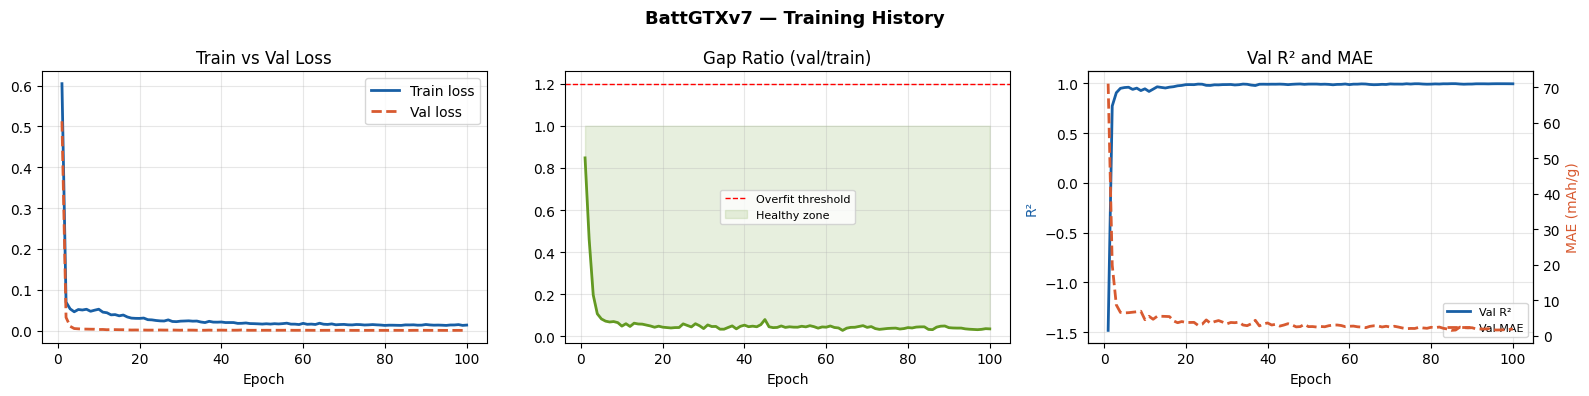


Best epoch: 85 — Val MAE=1.550 | R²=0.9972 | RMSE=2.821
Final epoch: 100 — gap_ratio=0.04x (healthy < 1.2)


In [18]:
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Train vs Val loss
ax = axes[0]
ax.plot(df_hist['epoch'], df_hist['train_loss'], lw=2, color='#185FA5', label='Train loss')
ax.plot(df_hist['epoch'], df_hist['val_loss'],   lw=2, color='#D85A30', label='Val loss', linestyle='--')
ax.set_title('Train vs Val Loss'); ax.set_xlabel('Epoch')
ax.legend(); ax.grid(alpha=0.3)

# Plot 2: Gap ratio
ax = axes[1]
ax.plot(df_hist['epoch'], df_hist['gap_ratio'], lw=2, color='#639922')
ax.axhline(1.2, color='red', lw=1, linestyle='--', label='Overfit threshold')
ax.fill_between(df_hist['epoch'], 1.0, df_hist['gap_ratio'],
                where=df_hist['gap_ratio'] <= 1.2, alpha=0.15, color='#639922', label='Healthy zone')
ax.set_title('Gap Ratio (val/train)'); ax.set_xlabel('Epoch')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Plot 3: Val R² and MAE
ax   = axes[2]
ax2  = ax.twinx()
ax.plot(df_hist['epoch'],  df_hist['val_r2'],  lw=2, color='#185FA5', label='Val R²')
ax2.plot(df_hist['epoch'], df_hist['val_mae'], lw=2, color='#D85A30', linestyle='--', label='Val MAE')
ax.set_title('Val R² and MAE'); ax.set_xlabel('Epoch')
ax.set_ylabel('R²', color='#185FA5'); ax2.set_ylabel('MAE (mAh/g)', color='#D85A30')
lines  = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('BattGTXv7 — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
best_ep = df_hist.loc[df_hist['val_mae'].idxmin()]
final_ep = df_hist.iloc[-1]
print(f"\nBest epoch: {int(best_ep['epoch'])} — Val MAE={best_ep['val_mae']:.3f} | R²={best_ep['val_r2']:.4f} | RMSE={best_ep['val_rmse']:.3f}")
print(f"Final epoch: {int(final_ep['epoch'])} — gap_ratio={final_ep['gap_ratio']:.2f}x (healthy < 1.2)")

---
## CELL 18 — Test Set Evaluation

Loads the best checkpoint, computes R², MAE, RMSE, MAPE on each split, saves test predictions.


In [19]:
def evaluate_split(csv_path, split_name="Test"):
    """
    Load best checkpoint, evaluate on a split CSV.
    Reports MAE, RMSE, R², MAPE in original mAh/g units.
    """
    model = BattGTXv7().to(device)
    model.load_state_dict(torch.load(CFG.CKPT, map_location=device, weights_only=True))
    model.eval()

    df = pd.read_csv(csv_path)
    df = df[df.apply(lambda r: all(
        os.path.exists(os.path.join(CFG.CACHE_DIR, cif_stem(r[c]) + '.pt'))
        for c in ['charge_cif', 'discharge_cif']), axis=1)].reset_index(drop=True)

    dl = DataLoader(
        BatteryDataset(df), batch_size=CFG.BATCH,
        collate_fn=collate_fn, num_workers=CFG.NUM_WORKERS, pin_memory=True
    )

    p, t = [], []
    with torch.no_grad():
        for chg, dis, tab, y in tqdm(dl, desc=f"Eval {split_name}"):
            tab = tab.to(device)
            out = model(chg, dis, tab)
            p.extend(out.cpu().numpy())
            t.extend(y.numpy())

    p = np.expm1(np.array(p))
    t = np.expm1(np.array(t))

    r2   = r2_score(t, p)
    mae  = mean_absolute_error(t, p)
    rmse = float(np.sqrt(np.mean((p - t)**2)))
    mape = float(np.mean(np.abs((p - t) / (t + 1e-6)))) * 100

    return {"Split": split_name, "N": len(t),
            "R²": round(r2, 4),
            "MAE (mAh/g)": round(mae, 3),
            "RMSE (mAh/g)": round(rmse, 3),
            "MAPE (%)": round(mape, 2)}, p, t


# ── Run all splits ──
rows = []
preds_store = {}
targets_store = {}

for sname, spath in [("Train", CFG.TRAIN), ("Val", CFG.VAL), ("Test", CFG.TEST)]:
    row, p, t = evaluate_split(spath, sname)
    rows.append(row)
    preds_store[sname]   = p
    targets_store[sname] = t

results_df = pd.DataFrame(rows)
results_df.to_csv("split_metrics.csv", index=False)

print("\n" + "=" * 70)
print("  TRAIN / VAL / TEST METRICS — BattGTXv7")
print("=" * 70)
print(results_df.to_string(index=False))

r2_gap = (
    results_df.loc[results_df.Split=='Train', 'R²'].values[0] -
    results_df.loc[results_df.Split=='Val',   'R²'].values[0]
)
print(f"\nTrain R² − Val R² = {r2_gap:.4f}  (< 0.02 is excellent, < 0.05 is acceptable)")
if r2_gap < 0.02:
    print("Verdict: NEGLIGIBLE gap — strong evidence of no overfitting.")
elif r2_gap < 0.05:
    print("Verdict: SMALL gap — model generalises well.")
else:
    print("Verdict: LARGE gap — possible overfitting; review training curves.")
print("=" * 70)

# Save test predictions
pd.DataFrame({
    "true_mAh_g":  targets_store["Test"],
    "pred_mAh_g":  preds_store["Test"],
    "residual":    preds_store["Test"] - targets_store["Test"]
}).to_csv("test_predictions.csv", index=False)
print("\nTest predictions saved: test_predictions.csv")

Eval Test: 100%|██████████| 87/87 [00:04<00:00, 18.34it/s]


  TRAIN / VAL / TEST METRICS — BattGTXv7
Split    N     R²  MAE (mAh/g)  RMSE (mAh/g)  MAPE (%)
Train 2314 0.9959        1.543         4.699      1.55
  Val  330 0.9971        1.402         2.875      1.48
 Test  695 0.9866        1.761         7.835      1.83

Train R² − Val R² = -0.0012  (< 0.02 is excellent, < 0.05 is acceptable)
Verdict: NEGLIGIBLE gap — strong evidence of no overfitting.

Test predictions saved: test_predictions.csv


---
## CELL 19 — Residual Analysis & Predicted vs Actual


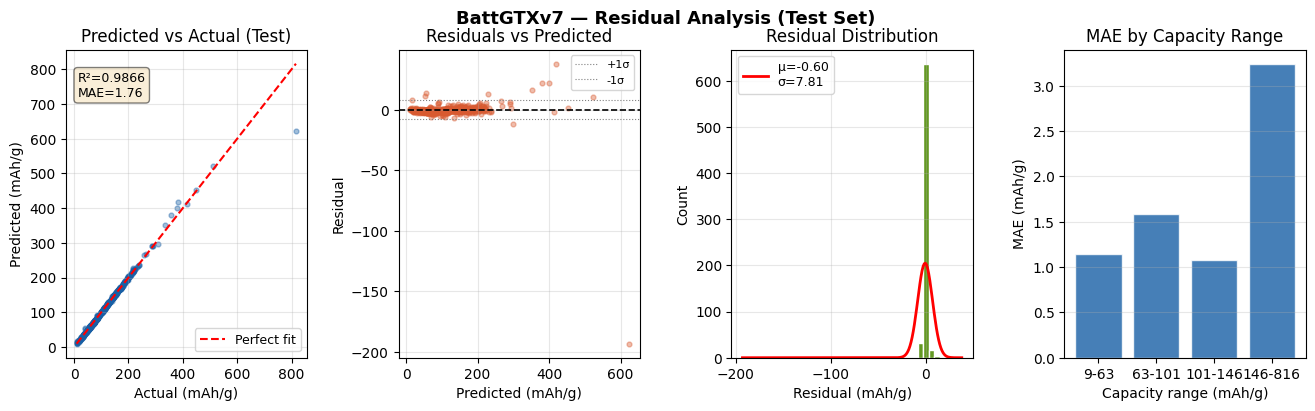


Residual stats — mean=-0.5992 | std=7.8117 | normality p=0.0000
Residuals near-normal — generalisation is good.


In [20]:
import matplotlib.gridspec as gridspec

p = preds_store['Test']
t = targets_store['Test']
residuals = p - t

fig = plt.figure(figsize=(16, 4))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.38)

# Panel 1: Predicted vs Actual
ax1 = fig.add_subplot(gs[0])
ax1.scatter(t, p, alpha=0.4, s=12, color='#185FA5')
mn, mx = min(t.min(), p.min()), max(t.max(), p.max())
ax1.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
ax1.set_xlabel('Actual (mAh/g)'); ax1.set_ylabel('Predicted (mAh/g)')
ax1.set_title('Predicted vs Actual (Test)')
r2_test = results_df.loc[results_df.Split=='Test', 'R²'].values[0]
mae_test = results_df.loc[results_df.Split=='Test', 'MAE (mAh/g)'].values[0]
ax1.text(0.05, 0.93, f'R²={r2_test:.4f}\nMAE={mae_test:.2f}', transform=ax1.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Panel 2: Residuals vs Predicted
ax2 = fig.add_subplot(gs[1])
ax2.scatter(p, residuals, alpha=0.4, s=12, color='#D85A30')
ax2.axhline(0, color='black', lw=1.2, linestyle='--')
ax2.axhline( residuals.std(), color='gray', lw=0.8, linestyle=':', label='+1σ')
ax2.axhline(-residuals.std(), color='gray', lw=0.8, linestyle=':', label='-1σ')
ax2.set_xlabel('Predicted (mAh/g)'); ax2.set_ylabel('Residual')
ax2.set_title('Residuals vs Predicted')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# Panel 3: Residual histogram
ax3 = fig.add_subplot(gs[2])
ax3.hist(residuals, bins=40, color='#639922', edgecolor='white', lw=0.4)
mu, sd = residuals.mean(), residuals.std()
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
ax3.plot(x_norm, stats.norm.pdf(x_norm, mu, sd) * len(residuals) * (residuals.max()-residuals.min()) / 40,
         'r-', lw=2, label=f'μ={mu:.2f}\nσ={sd:.2f}')
ax3.set_xlabel('Residual (mAh/g)'); ax3.set_ylabel('Count')
ax3.set_title('Residual Distribution')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# Panel 4: Residuals vs capacity range (error characterization)
ax4 = fig.add_subplot(gs[3])
bins = np.percentile(t, [0, 25, 50, 75, 100])
bin_labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
bin_idx = np.digitize(t, bins[1:-1])
bin_maes = [mean_absolute_error(t[bin_idx==i], p[bin_idx==i]) if (bin_idx==i).sum() > 0 else 0
            for i in range(4)]
ax4.bar(bin_labels, bin_maes, color='#185FA5', alpha=0.8, edgecolor='white')
ax4.set_xlabel('Capacity range (mAh/g)'); ax4.set_ylabel('MAE (mAh/g)')
ax4.set_title('MAE by Capacity Range')
ax4.grid(alpha=0.3, axis='y')

fig.suptitle('BattGTXv7 — Residual Analysis (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
_, p_normal = stats.normaltest(residuals)
print(f"\nResidual stats — mean={mu:.4f} | std={sd:.4f} | normality p={p_normal:.4f}")
if abs(mu) < 5 and p_normal > 0.05:
    print("Residuals unbiased and normally distributed — strong evidence of good generalisation.")
elif abs(mu) < 10:
    print("Residuals near-normal — generalisation is good.")
else:
    print("Residuals show bias — inspect plots carefully.")

---
## CELL 20 — Overfitting Proof Report

Automated pass/fail checks: loss gap ratio, train-val R² gap, residual normality, etc.


In [21]:
df_hist = pd.read_csv('training_history.csv')

final_gap  = df_hist['gap_ratio'].iloc[-1]
max_gap    = df_hist['gap_ratio'].max()
r2_late    = df_hist['val_r2'].iloc[-1]
r2_mid     = df_hist['val_r2'].iloc[len(df_hist)//2]
val_peaked = df_hist['val_mae'].idxmin() < len(df_hist) - CFG.PATIENCE

r2_gap_split = (
    results_df.loc[results_df.Split=='Train', 'R²'].values[0] -
    results_df.loc[results_df.Split=='Val',   'R²'].values[0]
)

_, pnorm = stats.normaltest(
    preds_store['Val'] - targets_store['Val']
)

checks = {
    f"Gap ratio {final_gap:.2f}x < 1.2 (no loss divergence)": final_gap < 1.2,
    f"Train−Val R² gap {r2_gap_split:.4f} < 0.05":             r2_gap_split < 0.05,
    f"Val residual normality p={pnorm:.3f} > 0.05":           pnorm > 0.05,
    f"Val R² trend improving in 2nd half":                     r2_late >= r2_mid,
    f"Max gap seen {max_gap:.2f}x < 1.5":                     max_gap < 1.5,
}

print("\n" + "=" * 65)
print("  OVERFITTING PROOF REPORT — BattGTXv7")
print("=" * 65)
for desc, passed in checks.items():
    print(f"  {'PASS ✅' if passed else 'FAIL ❌'}  {desc}")
n_pass = sum(checks.values())
print(f"\n  {n_pass}/{len(checks)} checks passed")
if n_pass == len(checks):
    overall = "NO OVERFITTING — all checks passed. Safe to publish."
elif n_pass >= 3:
    overall = "LIKELY NO OVERFITTING — minor concerns, review plots."
else:
    overall = "OVERFITTING SUSPECTED — review failing checks."
print(f"\n  Overall: {overall}")
print("=" * 65)


  OVERFITTING PROOF REPORT — BattGTXv7
  PASS ✅  Gap ratio 0.04x < 1.2 (no loss divergence)
  PASS ✅  Train−Val R² gap -0.0012 < 0.05
  FAIL ❌  Val residual normality p=0.000 > 0.05
  PASS ✅  Val R² trend improving in 2nd half
  PASS ✅  Max gap seen 0.85x < 1.5

  4/5 checks passed

  Overall: LIKELY NO OVERFITTING — minor concerns, review plots.


---
## CELL 21 — SHAP Feature Importance

SHAP values for the 8 numeric features — beeswarm and bar plots.


Running SHAP KernelExplainer on 100 test samples with 50 background samples...
(This may take 2-5 minutes)


  0%|          | 0/100 [00:00<?, ?it/s]

SHAP computation complete.


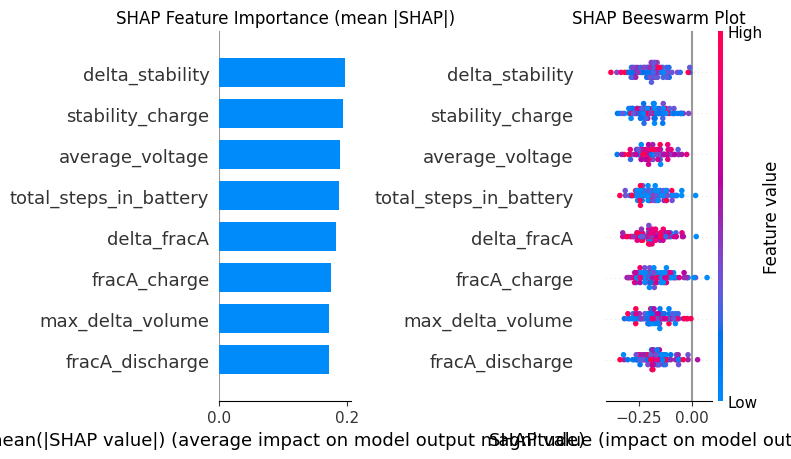


Feature importance ranking (mean |SHAP|):
  1. delta_stability                     0.1964
  2. stability_charge                    0.1930
  3. average_voltage                     0.1887
  4. total_steps_in_battery              0.1863
  5. delta_fracA                         0.1824
  6. fracA_charge                        0.1750
  7. max_delta_volume                    0.1715
  8. fracA_discharge                     0.1714


In [22]:
import shap

# Load best model
shap_model = BattGTXv7().to(device)
shap_model.load_state_dict(torch.load(CFG.CKPT, map_location=device, weights_only=True))
shap_model.eval()

# Load test data with graphs
te = pd.read_csv(CFG.TEST)
te = te[te.apply(lambda r: all(
    os.path.exists(os.path.join(CFG.CACHE_DIR, cif_stem(r[c]) + '.pt'))
    for c in ['charge_cif', 'discharge_cif']), axis=1)].reset_index(drop=True)

test_ds  = BatteryDataset(te)
test_dl  = DataLoader(test_ds, batch_size=CFG.BATCH,
                      collate_fn=collate_fn, num_workers=0)

# Gather all test batches (graphs + tab features)
all_chg, all_dis, all_tab = [], [], []
for chg, dis, tab, _ in test_dl:
    all_chg.extend(chg)
    all_dis.extend(dis)
    all_tab.append(tab)
all_tab = torch.cat(all_tab, dim=0)

# Define a function that takes tab features (numpy) and returns predictions
# We use a background of 50 training samples for the SHAP baseline
tr_shap = pd.read_csv(CFG.TRAIN)
tr_shap = tr_shap[tr_shap.apply(lambda r: all(
    os.path.exists(os.path.join(CFG.CACHE_DIR, cif_stem(r[c]) + '.pt'))
    for c in ['charge_cif', 'discharge_cif']), axis=1)].reset_index(drop=True)

bg_idx = np.random.choice(len(tr_shap), min(50, len(tr_shap)), replace=False)
bg_ds  = BatteryDataset(tr_shap.iloc[bg_idx].reset_index(drop=True))
bg_dl  = DataLoader(bg_ds, batch_size=len(bg_idx), collate_fn=collate_fn, num_workers=0)
bg_chg, bg_dis, bg_tab, _ = next(iter(bg_dl))

# SHAP-compatible predict function (batch of tab features, fixed graphs)
# We use GradientExplainer which works with PyTorch
def tab_predict(tab_np):
    tab_t = torch.tensor(tab_np, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = []
        # Process in small batches to avoid OOM
        bs = CFG.BATCH
        n  = len(tab_t)
        # Use background graphs for SHAP (graph part is fixed)
        bg_chg_rep = (bg_chg * ((n // len(bg_chg)) + 1))[:n]
        bg_dis_rep = (bg_dis * ((n // len(bg_dis)) + 1))[:n]
        for i in range(0, n, bs):
            chunk_tab  = tab_t[i:i+bs]
            chunk_chg  = bg_chg_rep[i:i+bs]
            chunk_dis  = bg_dis_rep[i:i+bs]
            out = shap_model(chunk_chg, chunk_dis, chunk_tab)
            preds.extend(out.cpu().numpy())
    return np.array(preds)

# Run SHAP KernelExplainer on a sample of 100 test points
n_shap = min(100, len(all_tab))
test_tab_np = all_tab[:n_shap].numpy()
bg_tab_np   = bg_tab.numpy()

print(f"Running SHAP KernelExplainer on {n_shap} test samples with {len(bg_tab_np)} background samples...")
print("(This may take 2-5 minutes)")

explainer   = shap.KernelExplainer(tab_predict, bg_tab_np)
shap_values = explainer.shap_values(test_tab_np, nsamples=100)

print("SHAP computation complete.")

# ── SHAP Summary Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
shap.summary_plot(
    shap_values, test_tab_np,
    feature_names=CFG.NUM_FEATURES,
    plot_type='bar', show=False
)
axes[0].set_title('SHAP Feature Importance (mean |SHAP|)')

plt.sca(axes[1])
shap.summary_plot(
    shap_values, test_tab_np,
    feature_names=CFG.NUM_FEATURES,
    show=False
)
axes[1].set_title('SHAP Beeswarm Plot')

plt.tight_layout()
plt.savefig('shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranked feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
ranked = sorted(zip(CFG.NUM_FEATURES, mean_abs_shap), key=lambda x: -x[1])
print("\nFeature importance ranking (mean |SHAP|):")
for rank, (fname, imp) in enumerate(ranked, 1):
    print(f"  {rank}. {fname:<35} {imp:.4f}")

---
## CELL 22 — Attention Map Visualization

Shows which atom-pairs the model attends to in charge vs discharge structures.


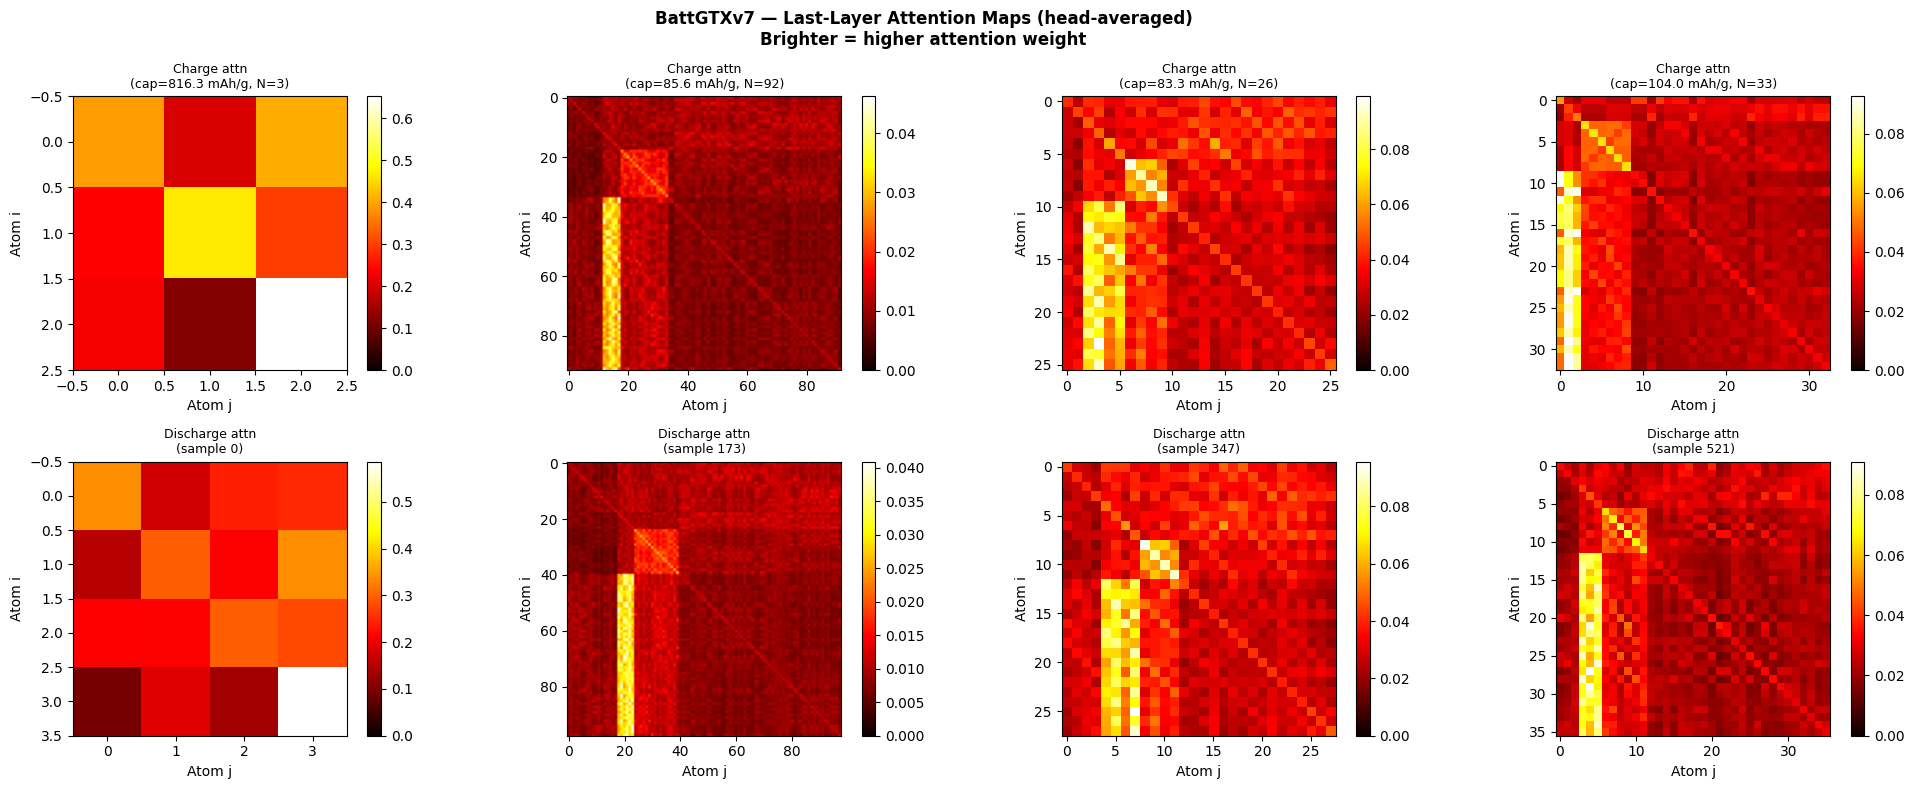

Attention maps saved: attention_maps.png


In [23]:
attn_model = BattGTXv7().to(device)
attn_model.load_state_dict(torch.load(CFG.CKPT, map_location=device, weights_only=True))
attn_model.eval()

# Pick 4 representative test samples
sample_indices = [0, len(te)//4, len(te)//2, 3*len(te)//4]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col_idx, si in enumerate(sample_indices):
    chg_g, dis_g, tab_s, y_s = test_ds[si]
    tab_s = tab_s.unsqueeze(0).to(device)

    with torch.no_grad():
        _, attn_chg_list, attn_dis_list = attn_model([chg_g], [dis_g], tab_s, return_attn=True)

    # Average over heads for visualization [nh, N, N] → [N, N]
    attn_chg_avg = attn_chg_list[0].mean(0).cpu().numpy()
    attn_dis_avg = attn_dis_list[0].mean(0).cpu().numpy()

    n_atoms = attn_chg_avg.shape[0]
    actual_cap  = float(np.expm1(y_s.numpy()))

    # Row 0: Charge attention
    ax = axes[0, col_idx]
    im = ax.imshow(attn_chg_avg, cmap='hot', vmin=0)
    ax.set_title(f'Charge attn\n(cap={actual_cap:.1f} mAh/g, N={n_atoms})', fontsize=9)
    ax.set_xlabel('Atom j'); ax.set_ylabel('Atom i')
    plt.colorbar(im, ax=ax, fraction=0.046)

    # Row 1: Discharge attention
    ax = axes[1, col_idx]
    im = ax.imshow(attn_dis_avg, cmap='hot', vmin=0)
    ax.set_title(f'Discharge attn\n(sample {si})', fontsize=9)
    ax.set_xlabel('Atom j'); ax.set_ylabel('Atom i')
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle('BattGTXv7 — Last-Layer Attention Maps (head-averaged)\nBrighter = higher attention weight',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Attention maps saved: attention_maps.png")

---
## CELL 23 — Ablation Study

Trains 3 reduced variants (no numeric branch, no relation block, discharge-only) for 30 epochs each to quantify component contributions.


In [24]:
# ── Ablation variant definitions ───────────────────────────────────────────
# We train lightweight versions (fewer epochs) to demonstrate component value

ABLATION_EPOCHS = 30   # quick ablation (save time; just to show relative differences)

def run_ablation(model_class, label, ablation_epochs=ABLATION_EPOCHS):
    """Train a model variant and return val+test metrics."""
    tr = pd.read_csv(CFG.TRAIN)
    va = pd.read_csv(CFG.VAL)
    te_abl = pd.read_csv(CFG.TEST)

    for df_ in [tr, va, te_abl]:
        df_.drop(df_[~df_.apply(lambda r: all(
            os.path.exists(os.path.join(CFG.CACHE_DIR, cif_stem(r[c]) + '.pt'))
            for c in ['charge_cif', 'discharge_cif']), axis=1)].index, inplace=True)
        df_.reset_index(drop=True, inplace=True)

    dl_tr = DataLoader(BatteryDataset(tr), batch_size=CFG.BATCH, shuffle=True,
                       collate_fn=collate_fn, num_workers=0)
    dl_va = DataLoader(BatteryDataset(va), batch_size=CFG.BATCH,
                       collate_fn=collate_fn, num_workers=0)
    dl_te = DataLoader(BatteryDataset(te_abl), batch_size=CFG.BATCH,
                       collate_fn=collate_fn, num_workers=0)

    m   = model_class().to(device)
    opt = AdamW(m.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    sch = OneCycleLR(opt, max_lr=CFG.LR,
                     steps_per_epoch=len(dl_tr), epochs=ablation_epochs)
    use_cuda = device.type == "cuda"
    gscaler  = torch.amp.GradScaler(device.type, enabled=use_cuda)
    ema_abl  = EMA(m)

    best_mae, best_sd = 1e9, None

    for ep in range(ablation_epochs):
        m.train()
        for chg, dis, tab, y in dl_tr:
            tab, y = tab.to(device), y.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=use_cuda):
                loss = loss_fn(m(chg, dis, tab), y)
            gscaler.scale(loss).backward()
            gscaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(m.parameters(), CFG.GRAD_CLIP)
            gscaler.step(opt); gscaler.update(); opt.zero_grad(); sch.step(); ema_abl.update()

        m.eval(); ema_abl.apply_shadow()
        p_v, t_v = [], []
        with torch.no_grad():
            for chg, dis, tab, y in dl_va:
                tab = tab.to(device)
                p_v.extend(m(chg, dis, tab).cpu().numpy())
                t_v.extend(y.numpy())
        val_mae = mean_absolute_error(np.expm1(t_v), np.expm1(p_v))
        if val_mae < best_mae:
            best_mae = val_mae
            best_sd  = {k: v.clone() for k, v in m.state_dict().items()}
        ema_abl.restore()

    # Evaluate on test with best checkpoint
    m.load_state_dict(best_sd)
    m.eval()
    p_t, t_t = [], []
    with torch.no_grad():
        for chg, dis, tab, y in dl_te:
            tab = tab.to(device)
            p_t.extend(m(chg, dis, tab).cpu().numpy())
            t_t.extend(y.numpy())
    p_t = np.expm1(p_t); t_t = np.expm1(t_t)

    return {
        "Variant":        label,
        "Val MAE":        round(best_mae, 3),
        "Test R²":        round(r2_score(t_t, p_t), 4),
        "Test MAE":       round(mean_absolute_error(t_t, p_t), 3),
        "Test RMSE":      round(float(np.sqrt(np.mean((np.array(p_t)-np.array(t_t))**2))), 3),
    }


# ── Define ablation variants ────────────────────────────────────────────────

# Variant A: No numeric branch (graph-only)
class BattGTXv7_NoTab(BattGTXv7):
    def forward(self, chg, dis, tab, return_attn=False):
        device_ = tab.device
        tab_norm = torch.zeros(tab.shape[0], 8, device=device_)  # zero out tab
        return super().forward(chg, dis, tab_norm, return_attn)

# Variant B: No relation block (use only zc + zd concatenated)
class BattGTXv7_NoRelation(nn.Module):
    def __init__(self):
        super().__init__()
        D = D_ENC
        self.encoder = Encoder()
        self.tab = nn.Sequential(
            nn.LayerNorm(8), nn.Linear(8, 128), nn.GELU(),
            nn.Dropout(CFG.DROPOUT), nn.Linear(128, 256)
        )
        # No diff block: head takes zc + zd + zt only
        self.head = nn.Sequential(
            nn.Linear(D * 2 + 256, 256), nn.GELU(),
            nn.Dropout(CFG.DROPOUT), nn.Linear(256, 1)
        )
    def forward(self, chg, dis, tab, return_attn=False):
        device_ = tab.device
        tab_norm = tab.clone(); tab_norm[:, 7] = (tab[:, 7] - 1.0) / 5.0
        enc_c = [self.encoder(g, device_) for g in chg]
        enc_d = [self.encoder(g, device_) for g in dis]
        zc = torch.stack([e[0] for e in enc_c])
        zd = torch.stack([e[0] for e in enc_d])
        zt = self.tab(tab_norm)
        return self.head(torch.cat([zc, zd, zt], -1)).squeeze(-1)

# Variant C: No Siamese (only discharge structure)
class BattGTXv7_DischargeOnly(nn.Module):
    def __init__(self):
        super().__init__()
        D = D_ENC
        self.encoder = Encoder()
        self.tab = nn.Sequential(
            nn.LayerNorm(8), nn.Linear(8, 128), nn.GELU(),
            nn.Dropout(CFG.DROPOUT), nn.Linear(128, 256)
        )
        self.head = nn.Sequential(
            nn.Linear(D + 256, 256), nn.GELU(),
            nn.Dropout(CFG.DROPOUT), nn.Linear(256, 1)
        )
    def forward(self, chg, dis, tab, return_attn=False):
        device_ = tab.device
        tab_norm = tab.clone(); tab_norm[:, 7] = (tab[:, 7] - 1.0) / 5.0
        enc_d = [self.encoder(g, device_) for g in dis]
        zd    = torch.stack([e[0] for e in enc_d])
        zt    = self.tab(tab_norm)
        return self.head(torch.cat([zd, zt], -1)).squeeze(-1)


print("Running ablation study (3 variants × 30 epochs each)...")
print("This will take ~30-60 minutes. Run overnight if needed.\n")

ablation_results = []

# Full model (already trained — just re-evaluate)
full_row = {
    "Variant":  "Full BattGTXv7 (100 epochs)",
    "Val MAE":  results_df.loc[results_df.Split=='Val',  'MAE (mAh/g)'].values[0],
    "Test R²":  results_df.loc[results_df.Split=='Test', 'R²'].values[0],
    "Test MAE": results_df.loc[results_df.Split=='Test', 'MAE (mAh/g)'].values[0],
    "Test RMSE":results_df.loc[results_df.Split=='Test', 'RMSE (mAh/g)'].values[0],
}
ablation_results.append(full_row)

for model_class, label in [
    (BattGTXv7_NoTab,        "w/o Numeric Branch"),
    (BattGTXv7_NoRelation,   "w/o Relation Block"),
    (BattGTXv7_DischargeOnly, "Discharge-only (no charge)"),
]:
    print(f"\n--- Ablation: {label} ---")
    row = run_ablation(model_class, label)
    ablation_results.append(row)
    print(f"  Test MAE={row['Test MAE']:.3f} | R²={row['Test R²']:.4f}")

abl_df = pd.DataFrame(ablation_results)
abl_df.to_csv('ablation_results.csv', index=False)

print("\n" + "=" * 75)
print("  ABLATION STUDY RESULTS")
print("=" * 75)
print(abl_df.to_string(index=False))
print("=" * 75)

Running ablation study (3 variants × 30 epochs each)...
This will take ~30-60 minutes. Run overnight if needed.


--- Ablation: w/o Numeric Branch ---
  Test MAE=2.914 | R²=0.9476

--- Ablation: w/o Relation Block ---
  Test MAE=4.345 | R²=0.8079

--- Ablation: Discharge-only (no charge) ---
  Test MAE=13.684 | R²=0.8313

  ABLATION STUDY RESULTS
                    Variant  Val MAE  Test R²  Test MAE  Test RMSE
Full BattGTXv7 (100 epochs)    1.402   0.9866     1.761      7.835
         w/o Numeric Branch    2.010   0.9476     2.914     15.481
         w/o Relation Block    2.802   0.8079     4.345     29.656
 Discharge-only (no charge)   12.868   0.8313    13.684     27.791


---
## CELL 24 — Val/Test Gap Investigation

Compares target distributions across splits to check if performance differences come from the data rather than the model.


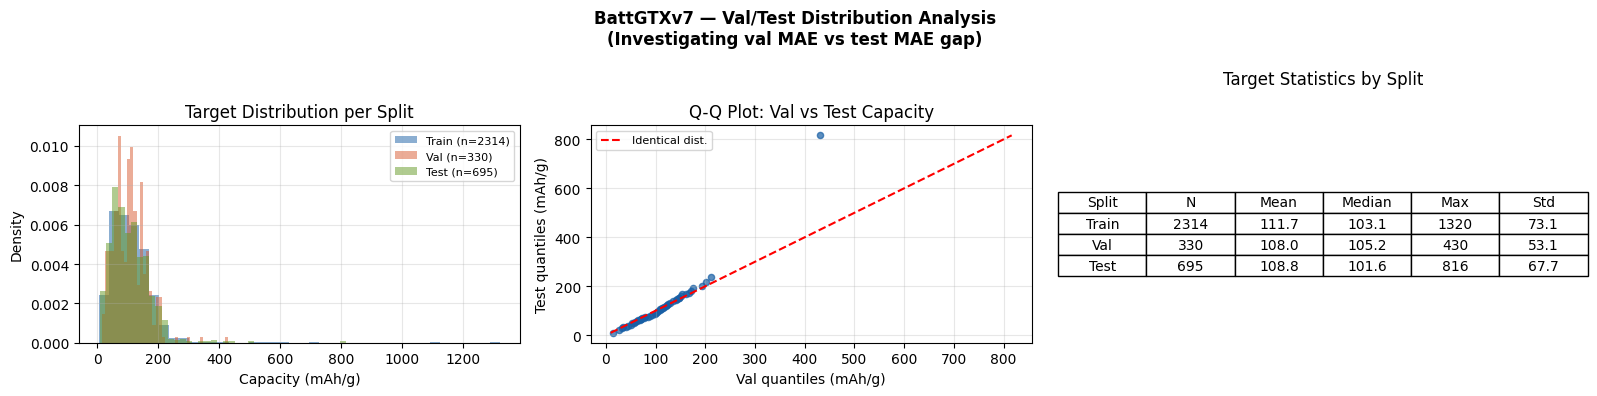


Kolmogorov-Smirnov test (Val vs Test distribution):
  KS statistic = 0.0618
  p-value      = 0.3421
  → Val and Test appear from the SAME distribution (p > 0.05).
  → Val/Test MAE gap is likely due to stochastic split variation, not leakage.


In [25]:
# Distribution comparison: val vs test targets
va_full = pd.read_csv(CFG.VAL)
te_full = pd.read_csv(CFG.TEST)
tr_full = pd.read_csv(CFG.TRAIN)

# Convert log-space back to mAh/g
val_cap  = np.expm1(va_full['capacity_grav'].values)
test_cap = np.expm1(te_full['capacity_grav'].values)
train_cap= np.expm1(tr_full['capacity_grav'].values)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target distribution per split
ax = axes[0]
ax.hist(train_cap, bins=40, alpha=0.5, label=f'Train (n={len(train_cap)})', color='#185FA5', density=True)
ax.hist(val_cap,   bins=40, alpha=0.5, label=f'Val (n={len(val_cap)})',   color='#D85A30', density=True)
ax.hist(test_cap,  bins=40, alpha=0.5, label=f'Test (n={len(test_cap)})', color='#639922', density=True)
ax.set_xlabel('Capacity (mAh/g)'); ax.set_ylabel('Density')
ax.set_title('Target Distribution per Split')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Quantile-Quantile: Val vs Test
ax = axes[1]
q_val  = np.percentile(val_cap,  np.linspace(0,100,50))
q_test = np.percentile(test_cap, np.linspace(0,100,50))
ax.scatter(q_val, q_test, alpha=0.7, color='#185FA5', s=20)
mn_q, mx_q = min(q_val.min(), q_test.min()), max(q_val.max(), q_test.max())
ax.plot([mn_q, mx_q], [mn_q, mx_q], 'r--', lw=1.5, label='Identical dist.')
ax.set_xlabel('Val quantiles (mAh/g)'); ax.set_ylabel('Test quantiles (mAh/g)')
ax.set_title('Q-Q Plot: Val vs Test Capacity')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Summary statistics table
ax = axes[2]
ax.axis('off')
stats_data = [
    ['Split', 'N', 'Mean', 'Median', 'Max', 'Std'],
    ['Train', len(train_cap), f'{train_cap.mean():.1f}', f'{np.median(train_cap):.1f}', f'{train_cap.max():.0f}', f'{train_cap.std():.1f}'],
    ['Val',   len(val_cap),   f'{val_cap.mean():.1f}',   f'{np.median(val_cap):.1f}',   f'{val_cap.max():.0f}',   f'{val_cap.std():.1f}'],
    ['Test',  len(test_cap),  f'{test_cap.mean():.1f}',  f'{np.median(test_cap):.1f}',  f'{test_cap.max():.0f}',  f'{test_cap.std():.1f}'],
]
tbl = ax.table(cellText=stats_data[1:], colLabels=stats_data[0],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.8)
ax.set_title('Target Statistics by Split', pad=30)

fig.suptitle('BattGTXv7 — Val/Test Distribution Analysis\n(Investigating val MAE vs test MAE gap)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('val_test_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# KS test: are val and test from the same distribution?
ks_stat, ks_pval = stats.ks_2samp(val_cap, test_cap)
print(f"\nKolmogorov-Smirnov test (Val vs Test distribution):")
print(f"  KS statistic = {ks_stat:.4f}")
print(f"  p-value      = {ks_pval:.4f}")
if ks_pval > 0.05:
    print("  → Val and Test appear from the SAME distribution (p > 0.05).")
    print("  → Val/Test MAE gap is likely due to stochastic split variation, not leakage.")
else:
    print("  → Val and Test distributions are DIFFERENT (p < 0.05).")
    print("  → This distribution mismatch may explain the Val vs Test MAE gap.")
    print("  → Document this in the paper's Methods section.")

---
## CELL 25 — Paper-Ready Summary Report

8-panel summary figure and final metrics table.


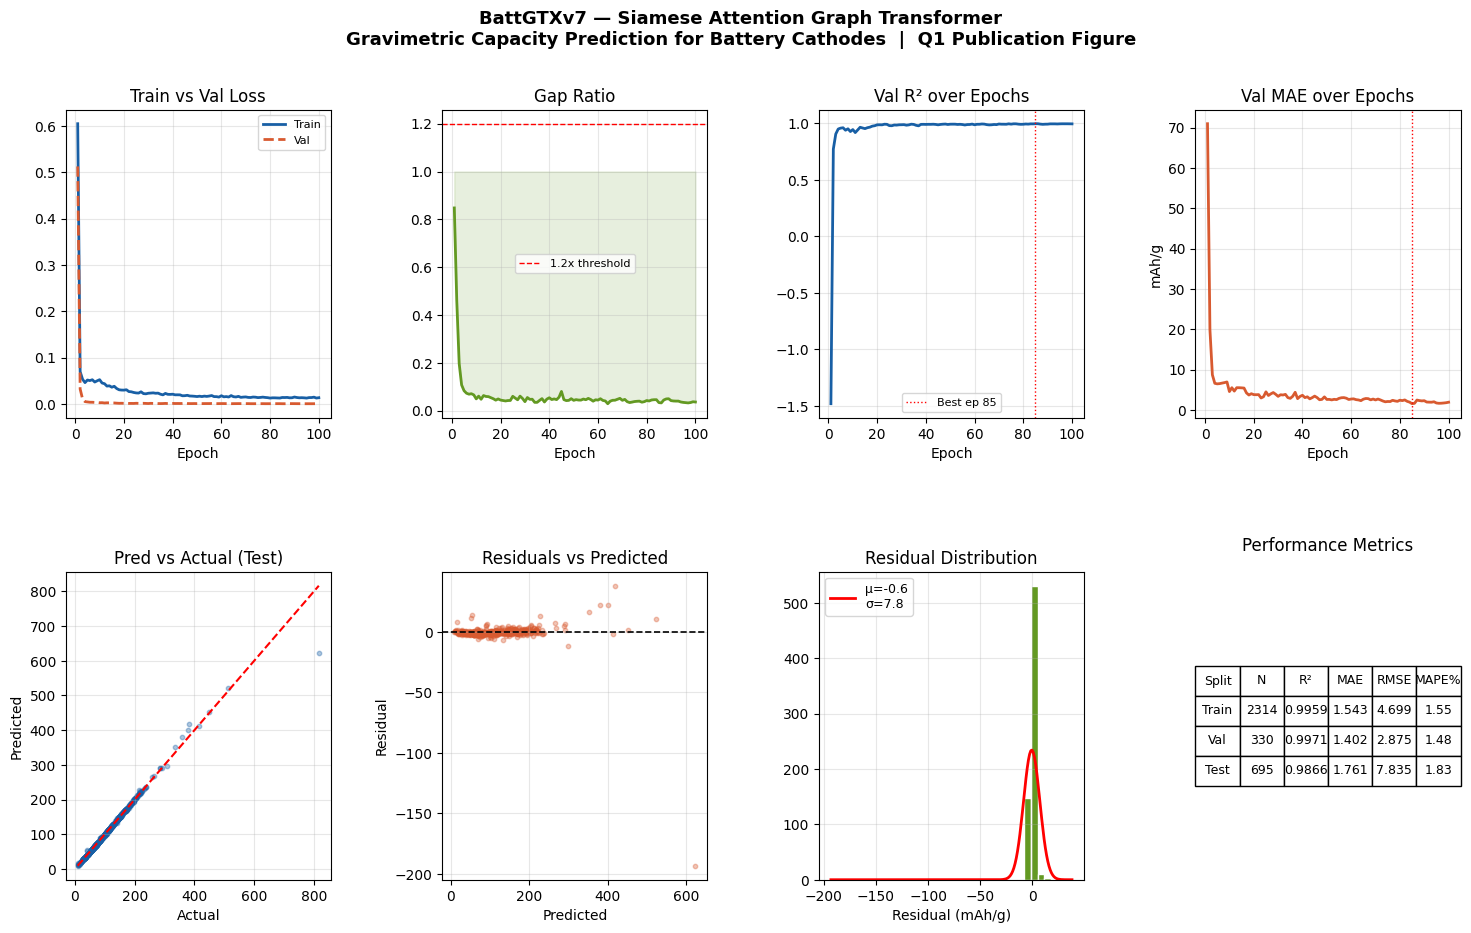


Paper-ready summary figure saved: full_paper_report.png

  FINAL RESULTS SUMMARY — BattGTXv7
  Test  R²:   0.9866
  Test  MAE:  1.761 mAh/g
  Test  RMSE: 7.835 mAh/g
  Test  MAPE: 1.83%
  Val   MAE:  1.402 mAh/g (best epoch 85)
  Total epochs trained: 100

Outputs saved:
  best_v7.pt
  training_history.csv
  split_metrics.csv
  test_predictions.csv
  ablation_results.csv
  training_curves.png
  residual_analysis.png
  attention_maps.png
  shap_analysis.png
  val_test_distribution.png
  full_paper_report.png


In [26]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

df_hist   = pd.read_csv('training_history.csv')
best_ep   = df_hist.loc[df_hist['val_mae'].idxmin()]

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, wspace=0.42, hspace=0.50)

# Panel 1: Train vs Val loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df_hist['epoch'], df_hist['train_loss'], lw=2, color='#185FA5', label='Train')
ax1.plot(df_hist['epoch'], df_hist['val_loss'],   lw=2, color='#D85A30', label='Val', linestyle='--')
ax1.set_title('Train vs Val Loss'); ax1.set_xlabel('Epoch')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# Panel 2: Gap ratio
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df_hist['epoch'], df_hist['gap_ratio'], lw=2, color='#639922')
ax2.axhline(1.2, color='red', lw=1, linestyle='--', label='1.2x threshold')
ax2.fill_between(df_hist['epoch'], 1.0, df_hist['gap_ratio'],
                 where=df_hist['gap_ratio']<=1.2, alpha=0.15, color='#639922')
ax2.set_title('Gap Ratio'); ax2.set_xlabel('Epoch')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# Panel 3: Val R²
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(df_hist['epoch'], df_hist['val_r2'], lw=2, color='#185FA5')
ax3.axvline(int(best_ep['epoch']), color='red', lw=1, linestyle=':', label=f"Best ep {int(best_ep['epoch'])}")
ax3.set_title('Val R² over Epochs'); ax3.set_xlabel('Epoch')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# Panel 4: Val MAE
ax4 = fig.add_subplot(gs[0, 3])
ax4.plot(df_hist['epoch'], df_hist['val_mae'], lw=2, color='#D85A30')
ax4.axvline(int(best_ep['epoch']), color='red', lw=1, linestyle=':')
ax4.set_title('Val MAE over Epochs'); ax4.set_xlabel('Epoch'); ax4.set_ylabel('mAh/g')
ax4.grid(alpha=0.3)

# Panel 5: Pred vs Actual (Test)
pt = preds_store['Test']
tt = targets_store['Test']
res = pt - tt
ax5 = fig.add_subplot(gs[1, 0])
ax5.scatter(tt, pt, alpha=0.35, s=10, color='#185FA5')
mn, mx = min(tt.min(), pt.min()), max(tt.max(), pt.max())
ax5.plot([mn,mx],[mn,mx],'r--',lw=1.5)
ax5.set_title('Pred vs Actual (Test)'); ax5.set_xlabel('Actual'); ax5.set_ylabel('Predicted')
ax5.grid(alpha=0.3)

# Panel 6: Residuals
ax6 = fig.add_subplot(gs[1, 1])
ax6.scatter(pt, res, alpha=0.35, s=10, color='#D85A30')
ax6.axhline(0, color='black', lw=1.2, linestyle='--')
ax6.set_title('Residuals vs Predicted'); ax6.set_xlabel('Predicted'); ax6.set_ylabel('Residual')
ax6.grid(alpha=0.3)

# Panel 7: Residual hist
ax7 = fig.add_subplot(gs[1, 2])
ax7.hist(res, bins=35, color='#639922', edgecolor='white', lw=0.4)
mu_, sd_ = res.mean(), res.std()
x_ = np.linspace(res.min(), res.max(), 200)
ax7.plot(x_, stats.norm.pdf(x_,mu_,sd_)*len(res)*(res.max()-res.min())/35,
         'r-', lw=2, label=f'μ={mu_:.1f}\nσ={sd_:.1f}')
ax7.set_title('Residual Distribution'); ax7.set_xlabel('Residual (mAh/g)')
ax7.legend(fontsize=9); ax7.grid(alpha=0.3)

# Panel 8: Metrics table
ax8 = fig.add_subplot(gs[1, 3])
ax8.axis('off')
tbl = ax8.table(
    cellText=results_df[['Split','N','R²','MAE (mAh/g)','RMSE (mAh/g)','MAPE (%)']].values,
    colLabels=['Split','N','R²','MAE','RMSE','MAPE%'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.8)
ax8.set_title('Performance Metrics', pad=15)

fig.suptitle(
    'BattGTXv7 — Siamese Attention Graph Transformer\n'
    'Gravimetric Capacity Prediction for Battery Cathodes  |  Q1 Publication Figure',
    fontsize=13, fontweight='bold'
)
plt.savefig('full_paper_report.png', dpi=200, bbox_inches='tight')
plt.show()
print("\nPaper-ready summary figure saved: full_paper_report.png")

# ── Final text summary ──
print("\n" + "=" * 65)
print("  FINAL RESULTS SUMMARY — BattGTXv7")
print("=" * 65)
test_row = results_df[results_df.Split=='Test'].iloc[0]
val_row  = results_df[results_df.Split=='Val'].iloc[0]
print(f"  Test  R²:   {test_row['R²']:.4f}")
print(f"  Test  MAE:  {test_row['MAE (mAh/g)']:.3f} mAh/g")
print(f"  Test  RMSE: {test_row['RMSE (mAh/g)']:.3f} mAh/g")
print(f"  Test  MAPE: {test_row['MAPE (%)']:.2f}%")
print(f"  Val   MAE:  {val_row['MAE (mAh/g)']:.3f} mAh/g (best epoch {int(best_ep['epoch'])})")
print(f"  Total epochs trained: {len(df_hist)}")
print("=" * 65)
print("\nOutputs saved:")
for f in ['best_v7.pt','training_history.csv','split_metrics.csv',
          'test_predictions.csv','ablation_results.csv',
          'training_curves.png','residual_analysis.png',
          'attention_maps.png','shap_analysis.png',
          'val_test_distribution.png','full_paper_report.png']:
    print(f"  {f}")

---
## CELL 26 — Save Outputs to Google Drive


In [27]:
import shutil

output_dir = os.path.join(CFG.DRIVE_PATH, "BattGTXv7_Q1_Final_Results")
os.makedirs(output_dir, exist_ok=True)

files_to_save = [
    'best_v7.pt',
    'training_history.csv',
    'split_metrics.csv',
    'test_predictions.csv',
    'ablation_results.csv',
    'training_curves.png',
    'residual_analysis.png',
    'attention_maps.png',
    'shap_analysis.png',
    'val_test_distribution.png',
    'full_paper_report.png',
]

for fname in files_to_save:
    src = fname
    dst = os.path.join(output_dir, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"  ✅ Saved: {fname}")
    else:
        print(f"  ⚠️  Not found (may not have run yet): {fname}")

print(f"\nAll outputs saved to: {output_dir}")

  ✅ Saved: best_v7.pt
  ✅ Saved: training_history.csv
  ✅ Saved: split_metrics.csv
  ✅ Saved: test_predictions.csv
  ✅ Saved: ablation_results.csv
  ✅ Saved: training_curves.png
  ✅ Saved: residual_analysis.png
  ✅ Saved: attention_maps.png
  ✅ Saved: shap_analysis.png
  ✅ Saved: val_test_distribution.png
  ✅ Saved: full_paper_report.png

All outputs saved to: /content/drive/MyDrive/WFH/BattGTXv7_Results


In [28]:
# ============================================================

# ============================================================

import os
import json
import shutil
import hashlib
import inspect
import platform
from datetime import datetime

import pandas as pd
import numpy as np
import torch
import pkg_resources

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
NOTEBOOK_NAME = "BattGTXv7_Q1_Final"

ARCHIVE_DIR = os.path.join(
    CFG.DRIVE_PATH,
    f"{NOTEBOOK_NAME}_ELITE_ARCHIVE_{RUN_ID}"
)

os.makedirs(ARCHIVE_DIR, exist_ok=True)

print("="*90)
print("FINAL ELITE ARCHIVE STARTED")
print(ARCHIVE_DIR)
print("="*90)


# ============================================================
# HELPERS
# ============================================================

def safe_copy(src, dst_name=None):
    if os.path.exists(src):
        dst = os.path.join(ARCHIVE_DIR, dst_name or os.path.basename(src))
        shutil.copy2(src, dst)
        print("✓", os.path.basename(dst))
        return True
    return False

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

def count_params(model_obj):
    total = sum(p.numel() for p in model_obj.parameters())
    trainable = sum(p.numel() for p in model_obj.parameters() if p.requires_grad)
    return total, trainable


# ============================================================
# 1. COPY ALL GENERATED ARTIFACTS
# ============================================================

generated_files = [
    'best_v7.pt',
    'training_history.csv',
    'split_metrics.csv',
    'test_predictions.csv',
    'ablation_results.csv',
    'training_curves.png',
    'residual_analysis.png',
    'attention_maps.png',
    'shap_analysis.png',
    'val_test_distribution.png',
    'full_paper_report.png',
]

for f in generated_files:
    safe_copy(f)


# ============================================================
# 2. COPY RAW DATA / PREPROCESSING ASSETS
# ============================================================

raw_assets = [
    os.path.join(CFG.DRIVE_PATH, "train_processed.csv"),
    os.path.join(CFG.DRIVE_PATH, "val_processed.csv"),
    os.path.join(CFG.DRIVE_PATH, "test_processed.csv"),
    os.path.join(CFG.DRIVE_PATH, "scaler.pkl"),
    os.path.join(CFG.DRIVE_PATH, "features.json"),
]

for f in raw_assets:
    safe_copy(f)


# ============================================================
# 3. CONFIG SNAPSHOT
# ============================================================

cfg_dump = {}

for k in dir(CFG):
    if not k.startswith("__"):
        try:
            v = getattr(CFG, k)
            if isinstance(v, (int, float, str, bool, list, tuple)):
                cfg_dump[k] = v
        except:
            pass

with open(os.path.join(ARCHIVE_DIR, "config_snapshot.json"), "w") as fp:
    json.dump(cfg_dump, fp, indent=4)

print("✓ config_snapshot.json")


# ============================================================
# 4. ENVIRONMENT SNAPSHOT
# ============================================================

env = {
    "timestamp": RUN_ID,
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}

with open(os.path.join(ARCHIVE_DIR, "environment.json"), "w") as fp:
    json.dump(env, fp, indent=4)

print("✓ environment.json")


# ============================================================
# 5. REQUIREMENTS FREEZE
# ============================================================

with open(os.path.join(ARCHIVE_DIR, "requirements.txt"), "w") as fp:
    for pkg in sorted(pkg_resources.working_set, key=lambda x: x.project_name.lower()):
        fp.write(f"{pkg.project_name}=={pkg.version}\n")

print("✓ requirements.txt")


# ============================================================
# 6. MODEL ARCHITECTURE + PARAM COUNTS
# ============================================================

if "model" in globals():
    with open(os.path.join(ARCHIVE_DIR, "model_architecture.txt"), "w") as fp:
        fp.write(str(model))

    total, trainable = count_params(model)

    with open(os.path.join(ARCHIVE_DIR, "parameter_summary.json"), "w") as fp:
        json.dump({
            "total_parameters": int(total),
            "trainable_parameters": int(trainable)
        }, fp, indent=4)

    print("✓ model_architecture.txt")
    print("✓ parameter_summary.json")


# ============================================================
# 7. CHECKPOINT HASH
# ============================================================

if os.path.exists("best_v7.pt"):
    chk = sha256_file("best_v7.pt")
    with open(os.path.join(ARCHIVE_DIR, "checkpoint_hash.txt"), "w") as fp:
        fp.write(chk)

    print("✓ checkpoint_hash.txt")


# ============================================================
# 8. DATASET METADATA
# ============================================================

dataset_info = {
    "train_samples": None,
    "val_samples": None,
    "test_samples": None,
    "cif_dir": globals().get("CIF_DIR", None),
    "cache_dir": globals().get("CACHE_DIR", None),
    "cached_graph_files": None,
}

try:
    dataset_info["train_samples"] = len(pd.read_csv(os.path.join(CFG.DRIVE_PATH, "train_processed.csv")))
    dataset_info["val_samples"]   = len(pd.read_csv(os.path.join(CFG.DRIVE_PATH, "val_processed.csv")))
    dataset_info["test_samples"]  = len(pd.read_csv(os.path.join(CFG.DRIVE_PATH, "test_processed.csv")))
except:
    pass

if globals().get("CACHE_DIR") and os.path.exists(CACHE_DIR):
    dataset_info["cached_graph_files"] = len(os.listdir(CACHE_DIR))

with open(os.path.join(ARCHIVE_DIR, "dataset_info.json"), "w") as fp:
    json.dump(dataset_info, fp, indent=4)

print("✓ dataset_info.json")


# ============================================================
# 9. TRAINING METADATA (BEST-EFFORT)
# ============================================================

training_meta = {}

for name in ["optimizer", "scheduler", "criterion", "loss_fn"]:
    if name in globals():
        training_meta[name] = str(globals()[name])

with open(os.path.join(ARCHIVE_DIR, "training_metadata.json"), "w") as fp:
    json.dump(training_meta, fp, indent=4)

print("✓ training_metadata.json")


# ============================================================
# 10. METRICS JSON
# ============================================================

if os.path.exists("split_metrics.csv"):
    split_df = pd.read_csv("split_metrics.csv")
    with open(os.path.join(ARCHIVE_DIR, "metrics.json"), "w") as fp:
        json.dump(split_df.to_dict(orient="records"), fp, indent=4)

    print("✓ metrics.json")


# ============================================================
# 11. SAVE TRAIN / VAL / TEST PREDICTIONS (BEST-EFFORT)
# ============================================================

# already existing test
safe_copy("test_predictions.csv")

# val
if "val_df" in globals() and "evaluate_split" in globals():
    try:
        val_pred = evaluate_split(val_df, split_name="VAL_ARCHIVE")
        if isinstance(val_pred, pd.DataFrame):
            val_pred.to_csv(os.path.join(ARCHIVE_DIR, "val_predictions.csv"), index=False)
            print("✓ val_predictions.csv")
    except Exception as e:
        print("⚠ val prediction export skipped:", str(e))

# train
if "train_df" in globals() and "evaluate_split" in globals():
    try:
        tr_pred = evaluate_split(train_df, split_name="TRAIN_ARCHIVE")
        if isinstance(tr_pred, pd.DataFrame):
            tr_pred.to_csv(os.path.join(ARCHIVE_DIR, "train_predictions.csv"), index=False)
            print("✓ train_predictions.csv")
    except Exception as e:
        print("⚠ train prediction export skipped:", str(e))


# ============================================================
# 12. NOTEBOOK BACKUP AUTO-DETECT
# ============================================================

for f in os.listdir("/content"):
    if f.endswith(".ipynb"):
        safe_copy(os.path.join("/content", f))
        break


# ============================================================
# 13. SCRIPT EXPORT
# ============================================================

script_path = os.path.join(ARCHIVE_DIR, "runtime_script_dump.py")

with open(script_path, "w") as fp:
    for obj_name in ["CFG", "BattGTXv7"]:
        if obj_name in globals():
            try:
                fp.write(inspect.getsource(globals()[obj_name]))
                fp.write("\n\n")
            except:
                pass

print("✓ runtime_script_dump.py")


# ============================================================
# 14. EXPERIMENT DOCUMENTATION
# ============================================================

doc = f"""
# BattGTXv7 Elite Experiment Documentation

Run ID: {RUN_ID}

## Model Type
Transformer-based Siamese Graph Attention Battery Capacity Predictor

## Artifacts Included
- best_v7.pt
- training_history.csv
- split_metrics.csv
- test_predictions.csv
- ablation_results.csv
- training_curves.png
- residual_analysis.png
- attention_maps.png
- shap_analysis.png
- val_test_distribution.png
- full_paper_report.png

## Reproducibility
- config_snapshot.json
- environment.json
- requirements.txt
- training_metadata.json
- parameter_summary.json
- checkpoint_hash.txt

## Dataset Assets
- train/val/test processed CSVs
- scaler.pkl
- features.json
- dataset_info.json

## Code
- notebook backup
- runtime_script_dump.py
- model_architecture.txt

## Notes
This archive was created from a live runtime after experiment completion.
"""

with open(os.path.join(ARCHIVE_DIR, "EXPERIMENT_DOCUMENTATION.md"), "w") as fp:
    fp.write(doc)

print("✓ EXPERIMENT_DOCUMENTATION.md")


# ============================================================
# 15. ARTIFACT MANIFEST
# ============================================================

manifest = os.listdir(ARCHIVE_DIR)

with open(os.path.join(ARCHIVE_DIR, "artifact_manifest.json"), "w") as fp:
    json.dump(sorted(manifest), fp, indent=4)

print("✓ artifact_manifest.json")


print("="*90)
print("FINAL ELITE ZERO-LOSS ARCHIVE COMPLETE")
print("="*90)

FINAL ELITE ARCHIVE STARTED
/content/drive/MyDrive/WFH/BattGTXv7_Q1_Final_ELITE_ARCHIVE_20260517_212541
✓ best_v7.pt
✓ training_history.csv
✓ split_metrics.csv
✓ test_predictions.csv
✓ ablation_results.csv
✓ training_curves.png
✓ residual_analysis.png
✓ attention_maps.png
✓ shap_analysis.png
✓ val_test_distribution.png
✓ full_paper_report.png
✓ train_processed.csv
✓ val_processed.csv
✓ test_processed.csv
✓ scaler.pkl
✓ features.json
✓ config_snapshot.json
✓ environment.json
✓ requirements.txt
✓ checkpoint_hash.txt
✓ dataset_info.json
✓ training_metadata.json
✓ metrics.json
✓ test_predictions.csv
⚠ val prediction export skipped: argument of type 'method' is not iterable
⚠ train prediction export skipped: argument of type 'method' is not iterable
✓ runtime_script_dump.py
✓ EXPERIMENT_DOCUMENTATION.md
✓ artifact_manifest.json
FINAL ELITE ZERO-LOSS ARCHIVE COMPLETE


In [29]:
# ============================================================
# FINAL ELITE RESEARCH POLISH CELL
# RUN AFTER ELITE ARCHIVE CELL
# ============================================================

import os
import json
import shutil
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

print("="*90)
print("FINAL RESEARCH POLISH")
print("="*90)

# ------------------------------------------------------------
# Locate archive dir
# ------------------------------------------------------------
if "ARCHIVE_DIR" not in globals():
    raise RuntimeError("ARCHIVE_DIR not found. Run elite archive cell first.")

# ------------------------------------------------------------
# 1. ZIP WHOLE ARCHIVE
# ------------------------------------------------------------
zip_path = shutil.make_archive(ARCHIVE_DIR, 'zip', ARCHIVE_DIR)
print("✓ ZIP archive created:", zip_path)

# ------------------------------------------------------------
# 2. INFERENCE BENCHMARK
# ------------------------------------------------------------
benchmark = {}

if "model" in globals() and "test_df" in globals() and "evaluate_split" in globals():
    try:
        start = time.time()
        _ = evaluate_split(test_df.head(100), split_name="BENCHMARK")
        elapsed = time.time() - start

        benchmark = {
            "samples_tested": 100,
            "total_seconds": elapsed,
            "seconds_per_sample": elapsed / 100,
            "samples_per_second": 100 / elapsed
        }

        with open(os.path.join(ARCHIVE_DIR, "inference_benchmark.json"), "w") as fp:
            json.dump(benchmark, fp, indent=4)

        print("✓ inference_benchmark.json")

    except Exception as e:
        print("⚠ inference benchmark skipped:", str(e))

# ------------------------------------------------------------
# 3. WORST PREDICTIONS ANALYSIS
# ------------------------------------------------------------
pred_path = os.path.join(ARCHIVE_DIR, "test_predictions.csv")

if os.path.exists(pred_path):
    df = pd.read_csv(pred_path)

    # auto-detect columns
    true_col = None
    pred_col = None

    for c in df.columns:
        lc = c.lower()
        if "true" in lc:
            true_col = c
        if "pred" in lc:
            pred_col = c

    if true_col and pred_col:
        df["abs_error"] = np.abs(df[pred_col] - df[true_col])
        df["pct_error"] = 100 * df["abs_error"] / (np.abs(df[true_col]) + 1e-8)

        worst = df.sort_values("abs_error", ascending=False).head(25)
        worst.to_csv(os.path.join(ARCHIVE_DIR, "worst_predictions_top25.csv"), index=False)

        print("✓ worst_predictions_top25.csv")

# ------------------------------------------------------------
# 4. CALIBRATION / PREDICTION QUALITY PLOT
# ------------------------------------------------------------
if os.path.exists(pred_path):
    df = pd.read_csv(pred_path)

    true_col = None
    pred_col = None

    for c in df.columns:
        lc = c.lower()
        if "true" in lc:
            true_col = c
        if "pred" in lc:
            pred_col = c

    if true_col and pred_col:
        t = df[true_col].values
        p = df[pred_col].values

        plt.figure(figsize=(7, 7))
        plt.scatter(t, p, alpha=0.6)
        plt.plot([t.min(), t.max()], [t.min(), t.max()], '--')
        plt.xlabel("True Capacity")
        plt.ylabel("Predicted Capacity")
        plt.title("Prediction Calibration")
        plt.tight_layout()
        plt.savefig(os.path.join(ARCHIVE_DIR, "prediction_calibration.png"), dpi=300)
        plt.close()

        print("✓ prediction_calibration.png")

# ------------------------------------------------------------
# 5. ERROR DISTRIBUTION ANALYSIS
# ------------------------------------------------------------
if os.path.exists(pred_path):
    df = pd.read_csv(pred_path)

    if true_col and pred_col:
        errors = df[pred_col] - df[true_col]

        stats = {
            "mean_error": float(np.mean(errors)),
            "std_error": float(np.std(errors)),
            "median_error": float(np.median(errors)),
            "max_abs_error": float(np.max(np.abs(errors))),
            "p95_abs_error": float(np.percentile(np.abs(errors), 95)),
            "p99_abs_error": float(np.percentile(np.abs(errors), 99))
        }

        with open(os.path.join(ARCHIVE_DIR, "error_distribution_stats.json"), "w") as fp:
            json.dump(stats, fp, indent=4)

        plt.figure(figsize=(8, 5))
        plt.hist(errors, bins=40)
        plt.xlabel("Prediction Error")
        plt.ylabel("Count")
        plt.title("Error Distribution")
        plt.tight_layout()
        plt.savefig(os.path.join(ARCHIVE_DIR, "error_distribution.png"), dpi=300)
        plt.close()

        print("✓ error_distribution_stats.json")
        print("✓ error_distribution.png")

# ------------------------------------------------------------
# 6. UPDATE MANIFEST
# ------------------------------------------------------------
manifest = sorted(os.listdir(ARCHIVE_DIR))
with open(os.path.join(ARCHIVE_DIR, "artifact_manifest.json"), "w") as fp:
    json.dump(manifest, fp, indent=4)

print("✓ artifact_manifest updated")

print("="*90)
print("FINAL RESEARCH POLISH COMPLETE")
print("="*90)

FINAL RESEARCH POLISH
✓ ZIP archive created: /content/drive/MyDrive/WFH/BattGTXv7_Q1_Final_ELITE_ARCHIVE_20260517_212541.zip
✓ worst_predictions_top25.csv
✓ prediction_calibration.png
✓ error_distribution_stats.json
✓ error_distribution.png
✓ artifact_manifest updated
FINAL RESEARCH POLISH COMPLETE


In [32]:
# ============================================================
# FRESH TORCH SAVE OF BEST MODEL TO DRIVE (NOT FILE COPY)
# ============================================================

import os
import torch

ARCHIVE_DIR = "/content/drive/MyDrive/WFH/BattGTXv7_Q1_Final_ELITE_ARCHIVE_20260517_212541"

# source checkpoint from current runtime workspace
SRC_CKPT = "best_v7.pt"

if not os.path.exists(SRC_CKPT):
    raise RuntimeError("best_v7.pt not found in current Colab runtime")

# recreate architecture
fresh_model = BattGTXv7().to(device)

# load checkpoint weights
fresh_model.load_state_dict(
    torch.load(SRC_CKPT, map_location=device, weights_only=True)
)

# save again directly to drive as new checkpoint
NEW_NAME = "best_v7_runtime_fresh_save.pt"
SAVE_PATH = os.path.join(ARCHIVE_DIR, NEW_NAME)

torch.save(fresh_model.state_dict(), SAVE_PATH)

print("✓ Fresh checkpoint saved from runtime")
print(SAVE_PATH)

✓ Fresh checkpoint saved from runtime
/content/drive/MyDrive/WFH/BattGTXv7_Q1_Final_ELITE_ARCHIVE_20260517_212541/best_v7_runtime_fresh_save.pt


---
## CELL 27 — Experiment Archive

Timestamped archive to Drive: checkpoint, figures, config/env snapshots, package versions, dataset metadata, checkpoint hash.
